In [101]:
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(suppress=True)

import os
import scanpy as sc
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

In [102]:
adata = sc.read_h5ad('../datasets/Mouse_Hematopoiesis/adata_used.h5ad')
adata

AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [103]:
adata.var_names_make_unique()
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
idx_mt = [not gene.startswith('mt-') for gene in adata.var.index]
adata = adata[:, idx_mt]
adata

View of AnnData object with n_obs × n_vars = 44756 × 4995
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### Panel A-B

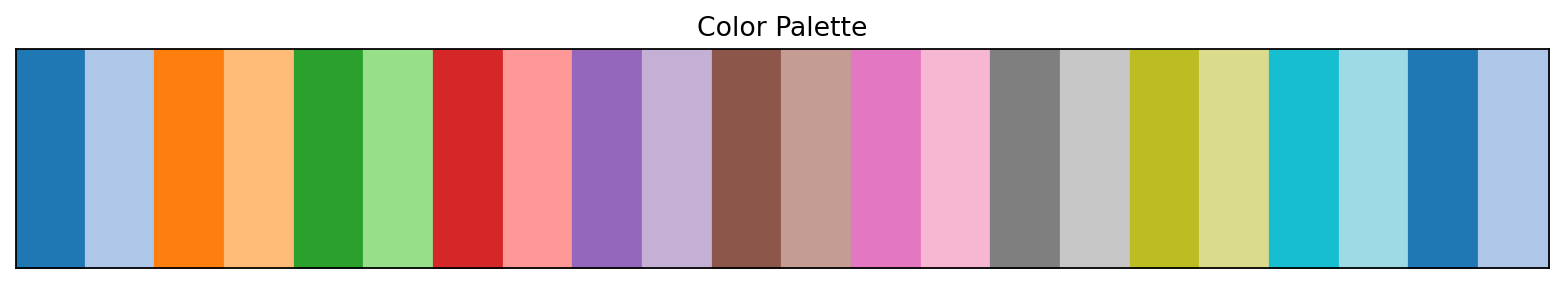

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# List of colors
colors = [
    '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a',
    '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', '#c49c94',
    '#e377c2', '#f7b6d2', '#7f7f7f', '#c7c7c7', '#bcbd22', '#dbdb8d',
    '#17becf', '#9edae5', '#1f77b4', '#aec7e8'
]

# Create a figure to display the colors
fig, ax = plt.subplots(figsize=(10, 2))
ax.set_title("Color Palette", fontsize=12)

# Plot each color as a horizontal bar
for i, color in enumerate(colors):
    ax.fill_between([i, i+1], 0, 1, color=color)

# Remove axes ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


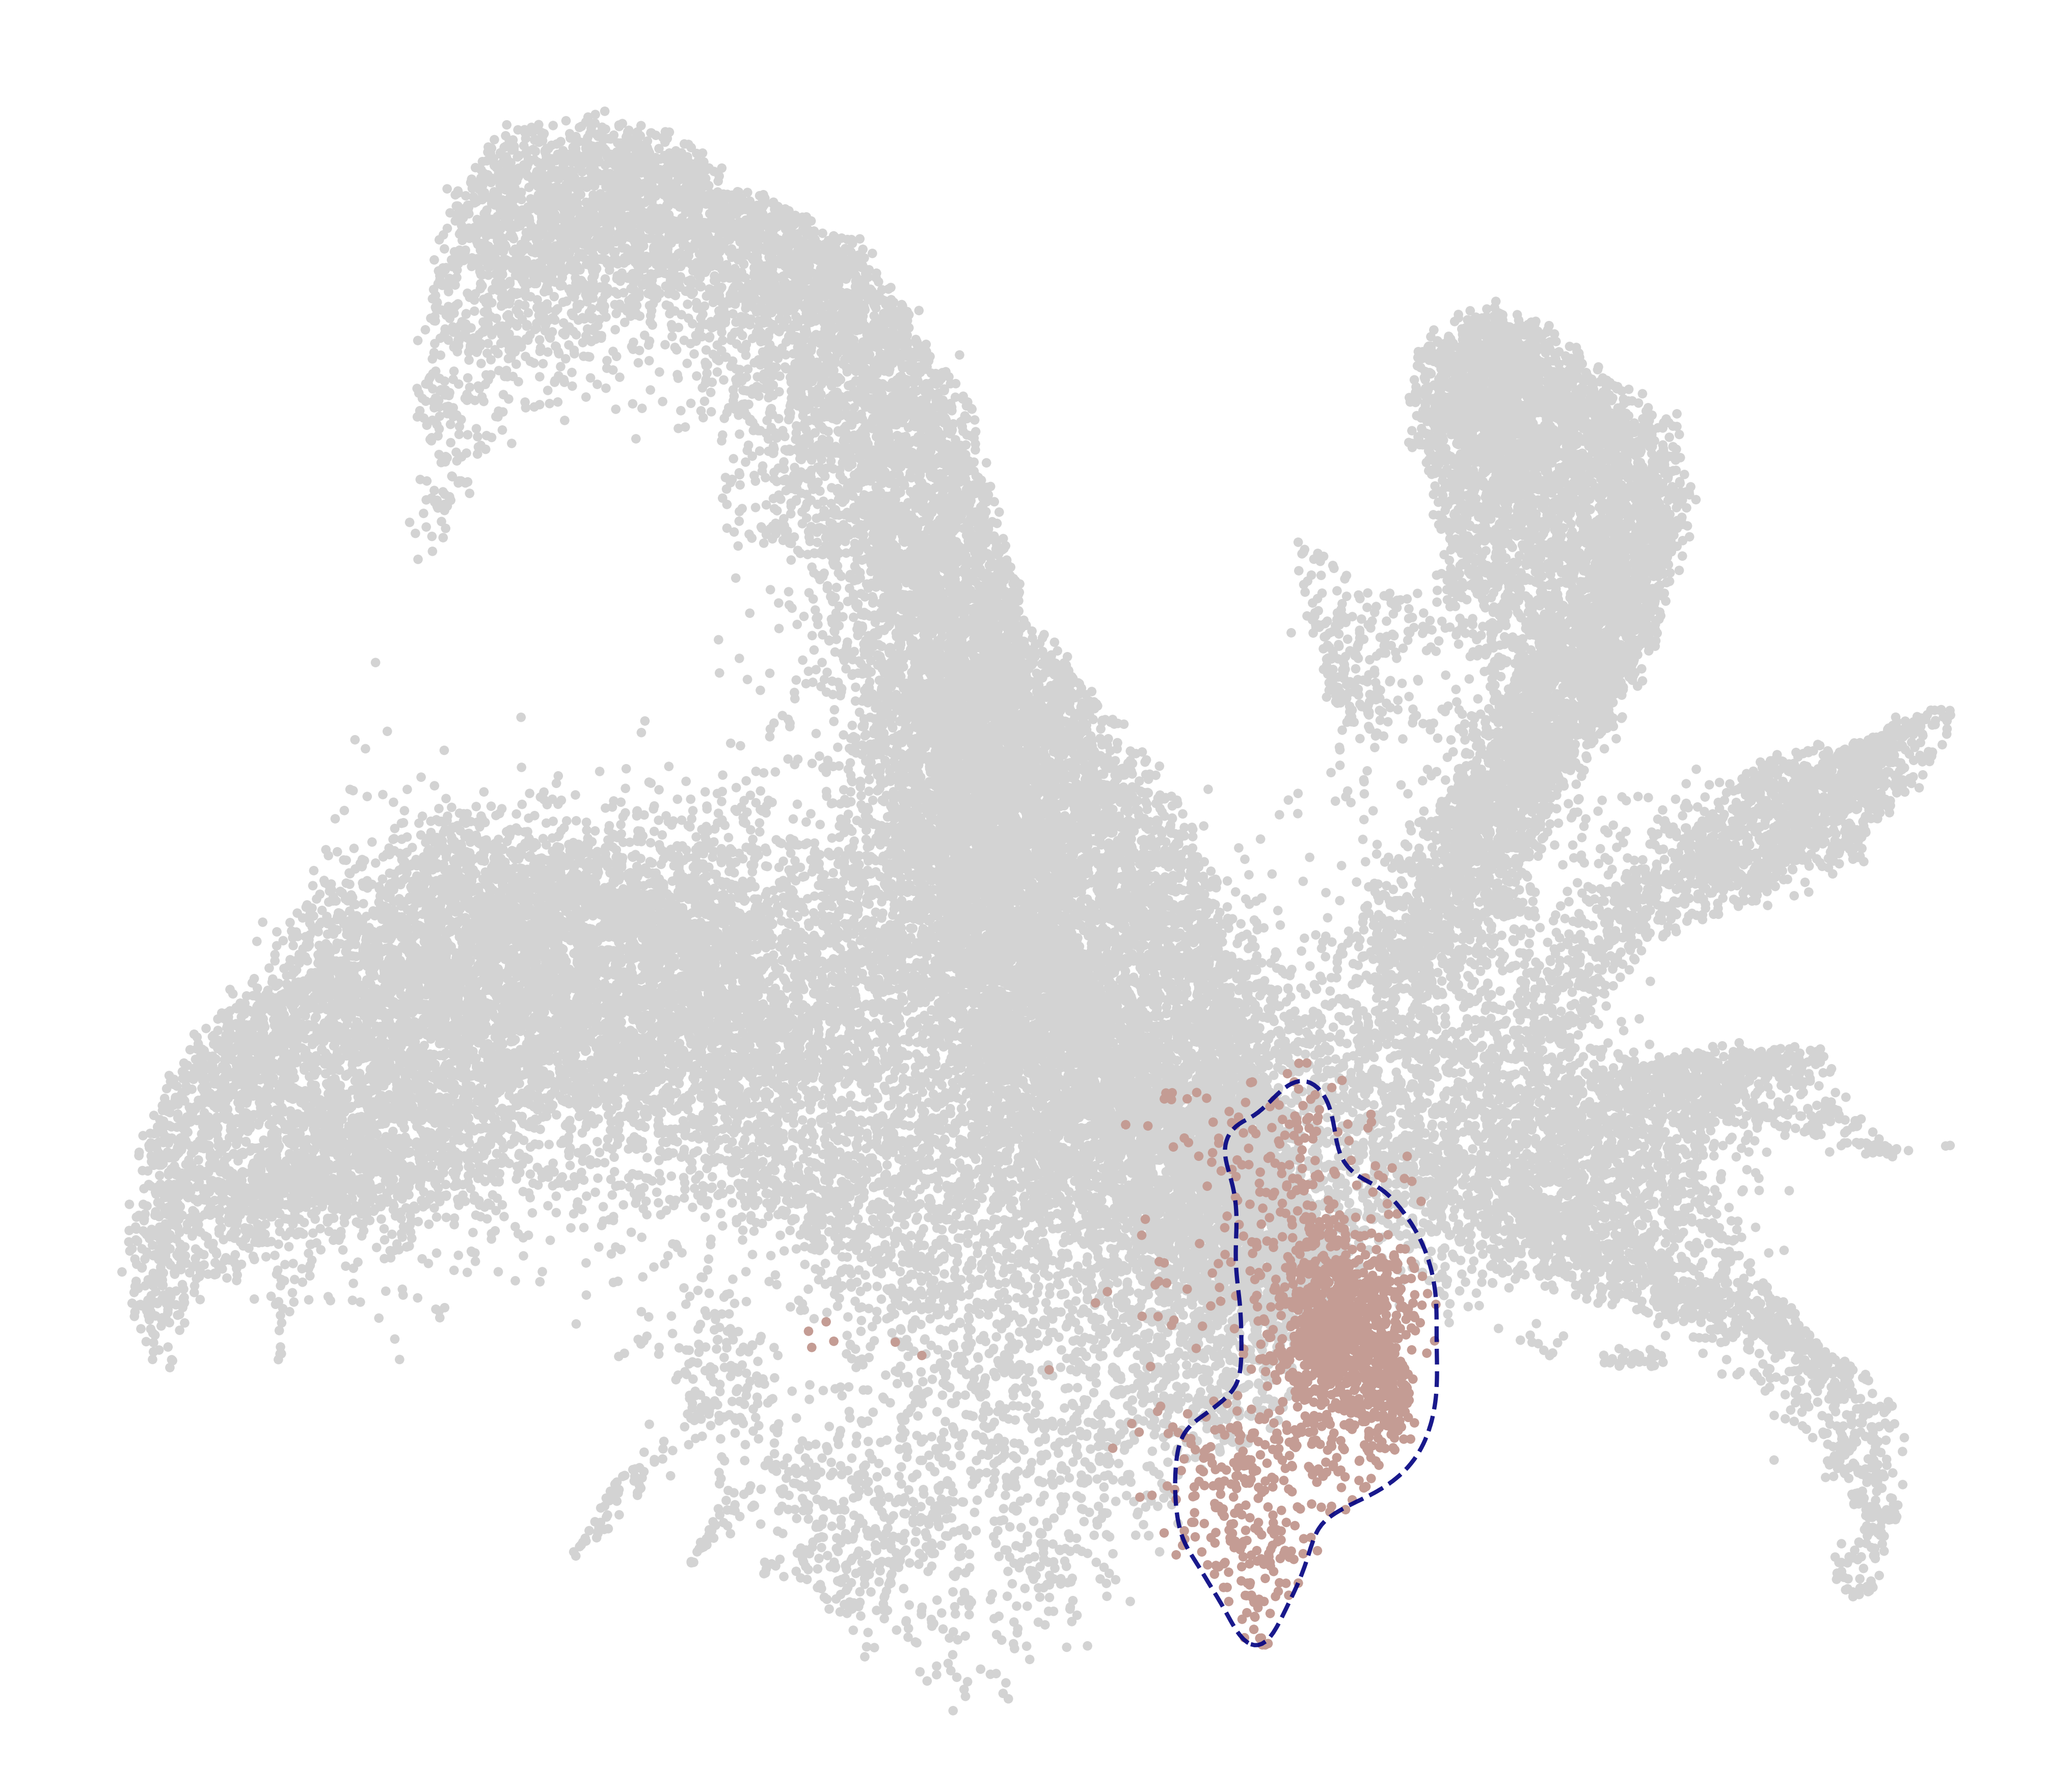

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with constrained layout
fig, ax = plt.subplots(figsize=(7, 6), dpi=300, facecolor='white')
plt.grid(False)  # Remove background grid

# Plot UMAP (critical: use show=False)
sc.pl.umap(
    adata,
    color=['label_man'],
    groups='prog_1',
    size=20,
    legend_loc='right margin',
    frameon=False,
    title='',
    legend_fontsize=20,  # Smaller legend for elegance
    ax=ax,
    show=False  # Essential for adding layers
)

# Extract coordinates
prog1_mask = adata.obs['label_man'] == 'prog_1'
umap_coords = adata.obsm['X_umap'][prog1_mask]

# Enhanced KDE contour
sns.kdeplot(
    x=umap_coords[:, 0],
    y=umap_coords[:, 1],
    levels=[0.1],  # Tight contour (adjust between 0.1-0.5)
    color='navy',  # Professional color
    linewidths=1.0,
    linestyles='--',
    alpha=0.9,
    ax=ax,
    zorder=3,  # Ensure contour is above points
    fill=False,  # No fill for cleaner look
    bw_adjust=1.0  # Smoother contour (0.5-1.5)
)

# Add minimal legend (optional)
from matplotlib.lines import Line2D
legend_elements = []
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=15)

plt.tight_layout()
plt.savefig('./umap_prog1.svg', dpi=300, bbox_inches='tight', transparent=True)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


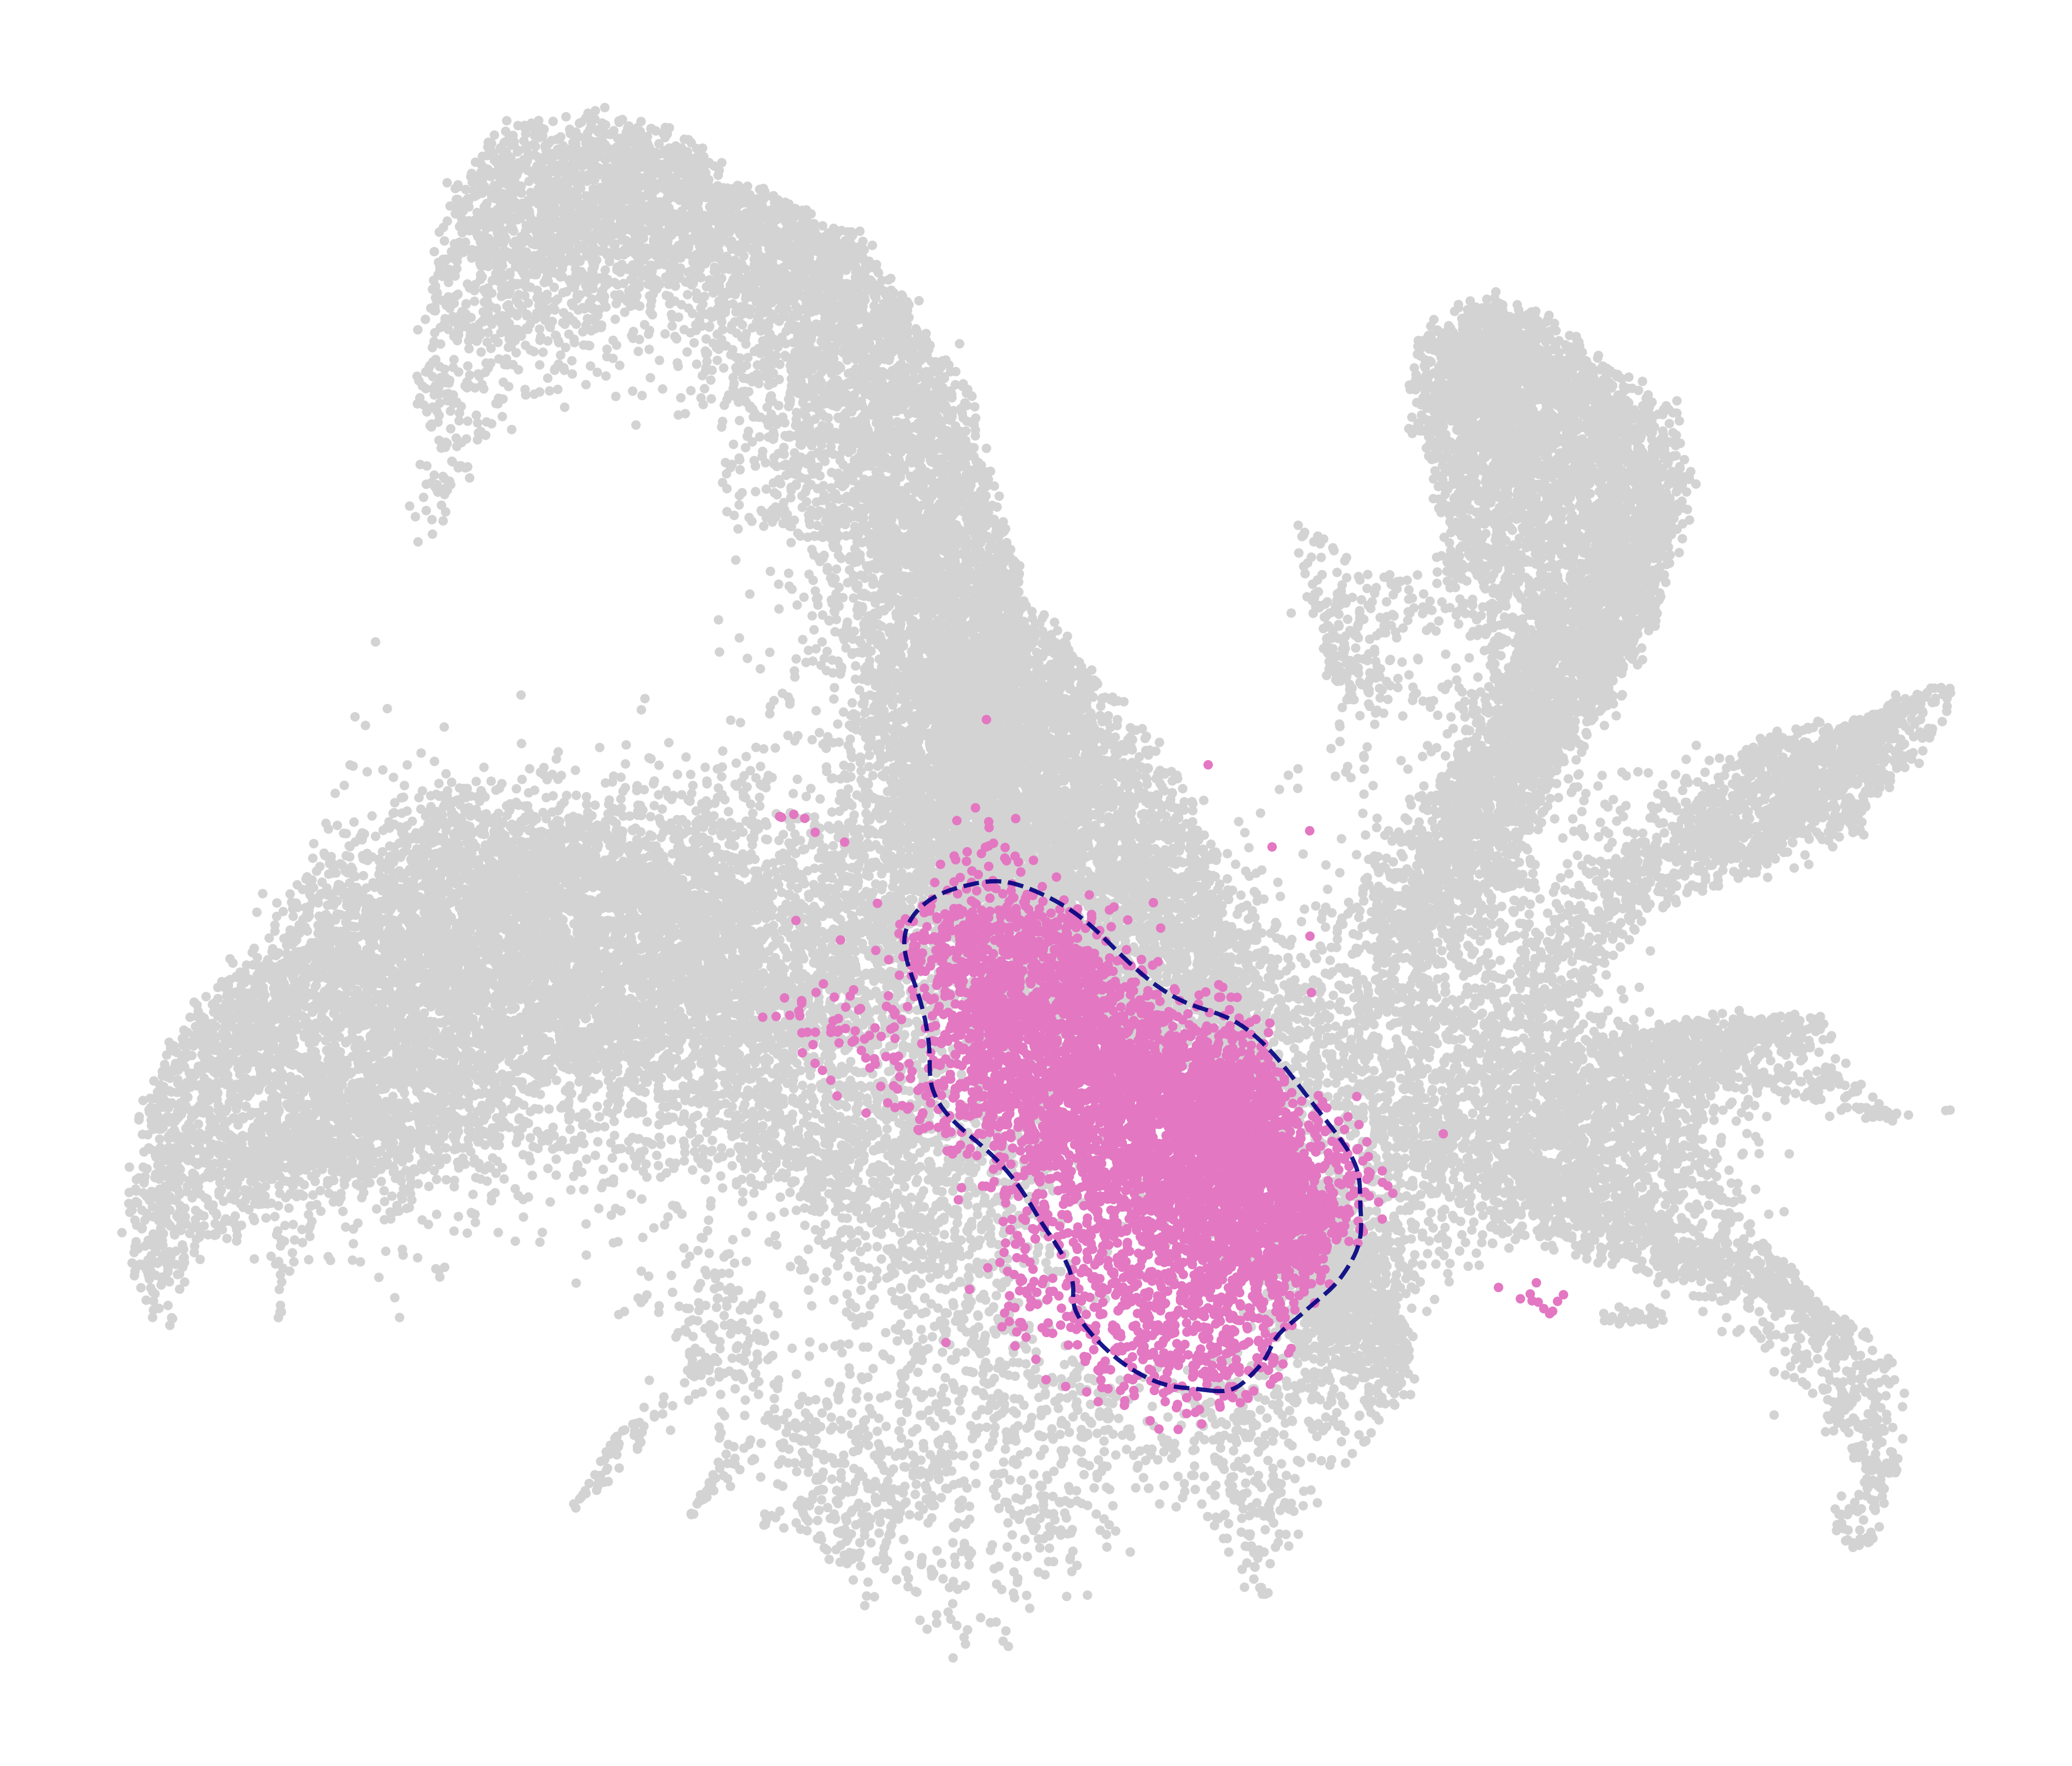

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with constrained layout
fig, ax = plt.subplots(figsize=(7, 6), dpi=300, facecolor='white')
plt.grid(False)  # Remove background grid

# Plot UMAP (critical: use show=False)
sc.pl.umap(
    adata,
    color=['label_man'],
    groups='prog_2',
    size=20,
    legend_loc='right margin',
    frameon=False,
    title='',
    legend_fontsize=20,  # Smaller legend for elegance
    ax=ax,
    show=False  # Essential for adding layers
)

# Extract coordinates
prog1_mask = adata.obs['label_man'] == 'prog_2'
umap_coords = adata.obsm['X_umap'][prog1_mask]

# Enhanced KDE contour
sns.kdeplot(
    x=umap_coords[:, 0],
    y=umap_coords[:, 1],
    levels=[0.1],  # Tight contour (adjust between 0.1-0.5)
    color='navy',  # Professional color
    linewidths=1.0,
    linestyles='--',
    alpha=0.9,
    ax=ax,
    zorder=3,  # Ensure contour is above points
    fill=False,  # No fill for cleaner look
    bw_adjust=1.0  # Smoother contour (0.5-1.5)
)

# Add minimal legend (optional)
from matplotlib.lines import Line2D
legend_elements = []
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=15)

plt.tight_layout()
plt.savefig('./umap_prog2.svg', dpi=300, bbox_inches='tight', transparent=True)

In [21]:
adata_prog1 = adata[adata.obs['label_man'] == 'prog_1', :]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


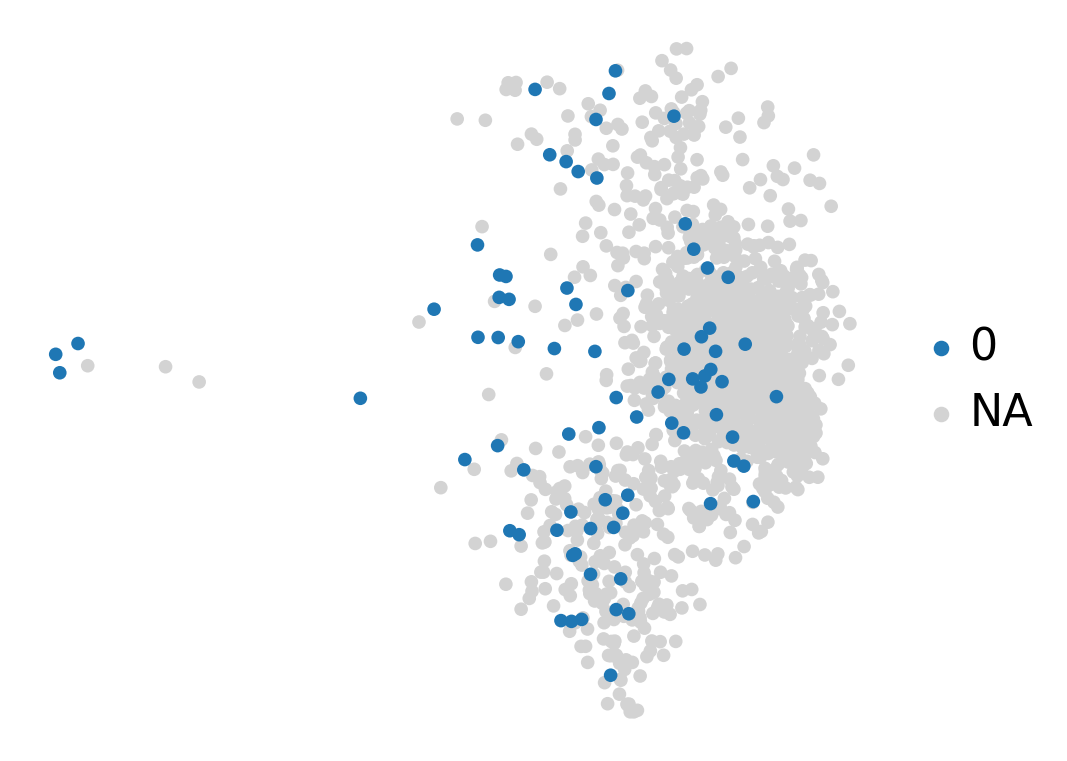

In [28]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata_prog1, color=['meta_clones'], size=150, legend_loc='right margin', groups='0',
    frameon=False, title='', legend_fontsize=20, save='umap_prog_1_clones_0.svg'
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


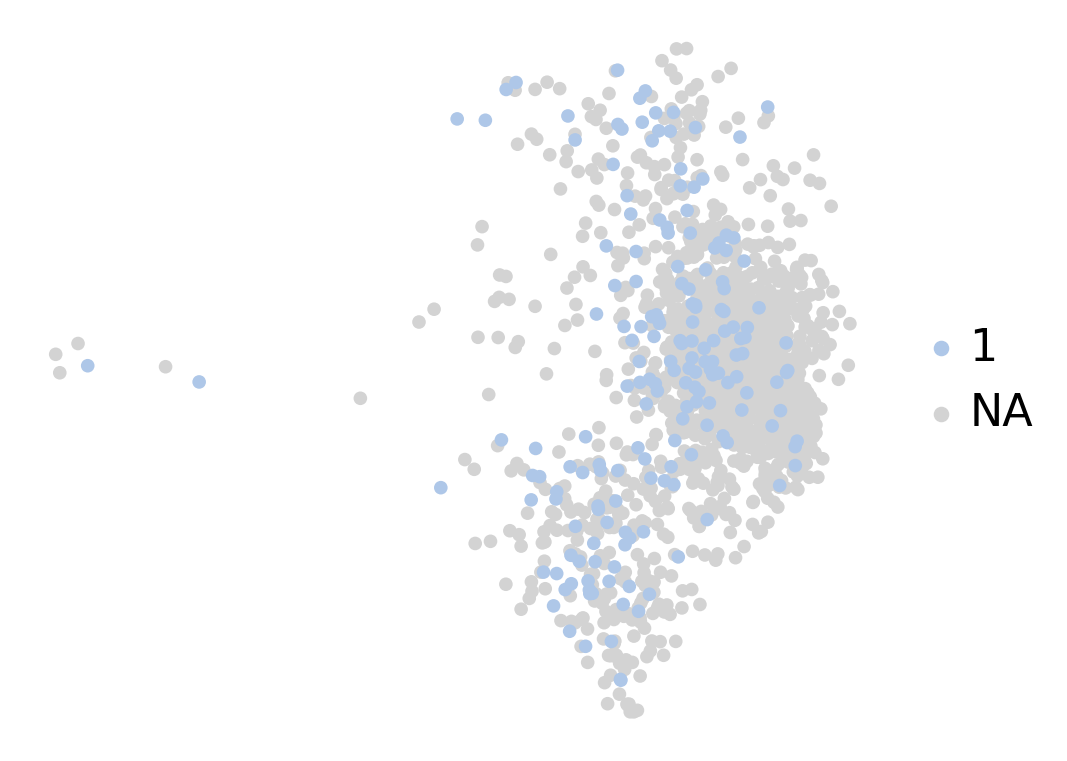

In [29]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata_prog1, color=['meta_clones'], size=150, legend_loc='right margin', groups='1',
    frameon=False, title='', legend_fontsize=20, save='umap_prog_1_clones_1.svg'
)

In [30]:
adata_prog2 = adata[adata.obs['label_man'] == 'prog_2', :]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


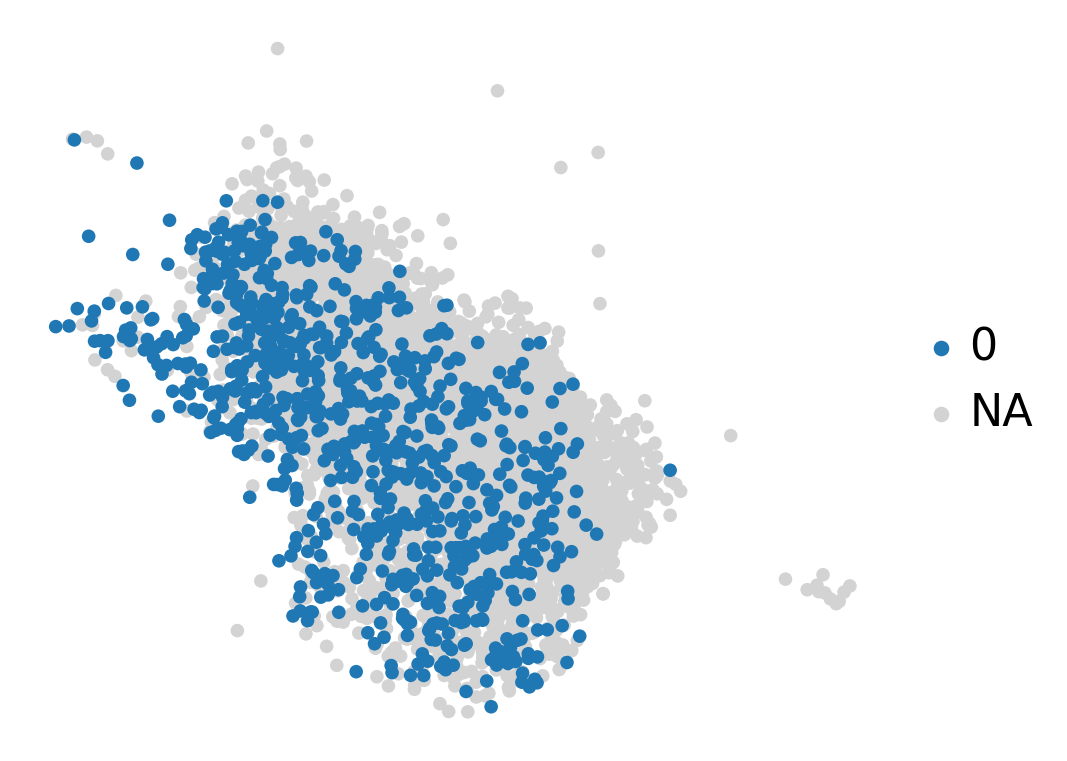

In [31]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata_prog2, color=['meta_clones'], size=150, legend_loc='right margin', groups='0',
    frameon=False, title='', legend_fontsize=20, save='umap_prog_2_clones_0.svg'
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


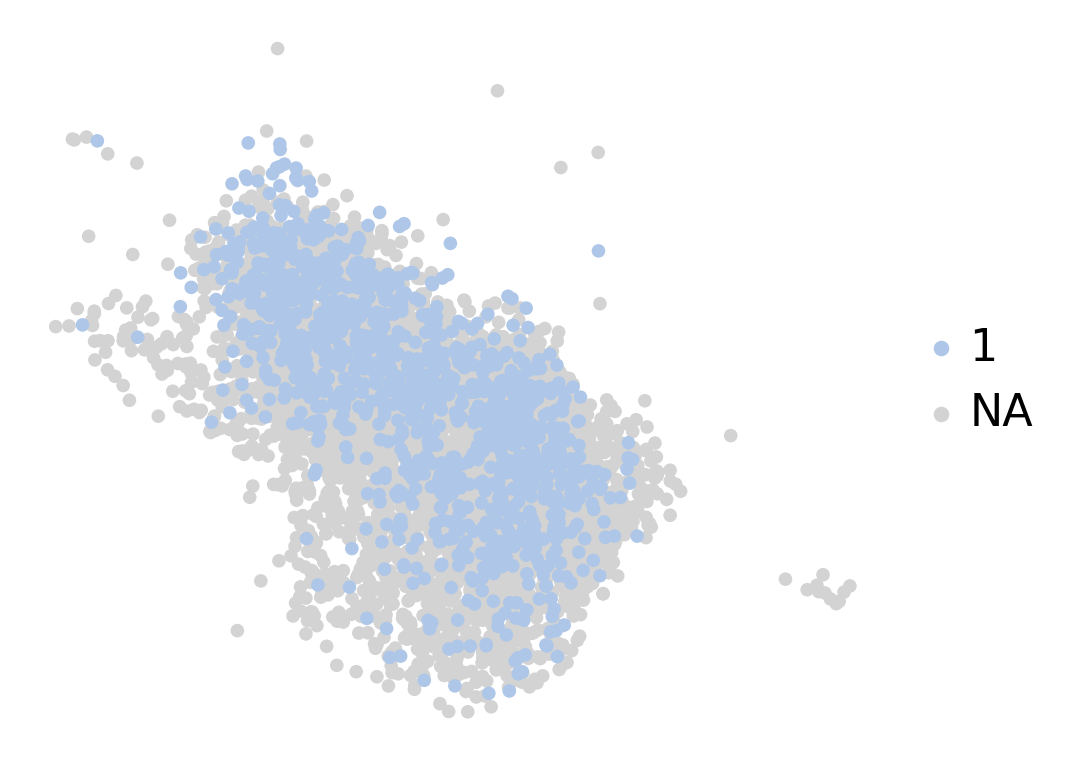

In [32]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata_prog2, color=['meta_clones'], size=150, legend_loc='right margin', groups='1',
    frameon=False, title='', legend_fontsize=20, save='umap_prog_2_clones_1.svg'
)

### Panel C

In [33]:
adata_prog1.shape

(1595, 4995)

In [35]:
for i in range(13):
    print (f'Meta-Clone {i}:', np.sum(adata_prog1.obs['meta_clones'].values == str(i)))

Meta-Clone 0: 79
Meta-Clone 1: 176
Meta-Clone 2: 41
Meta-Clone 3: 2
Meta-Clone 4: 100
Meta-Clone 5: 689
Meta-Clone 6: 143
Meta-Clone 7: 4
Meta-Clone 8: 348
Meta-Clone 9: 10
Meta-Clone 10: 3
Meta-Clone 11: 0
Meta-Clone 12: 0


In [38]:
del adata_prog1.uns['log1p']

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


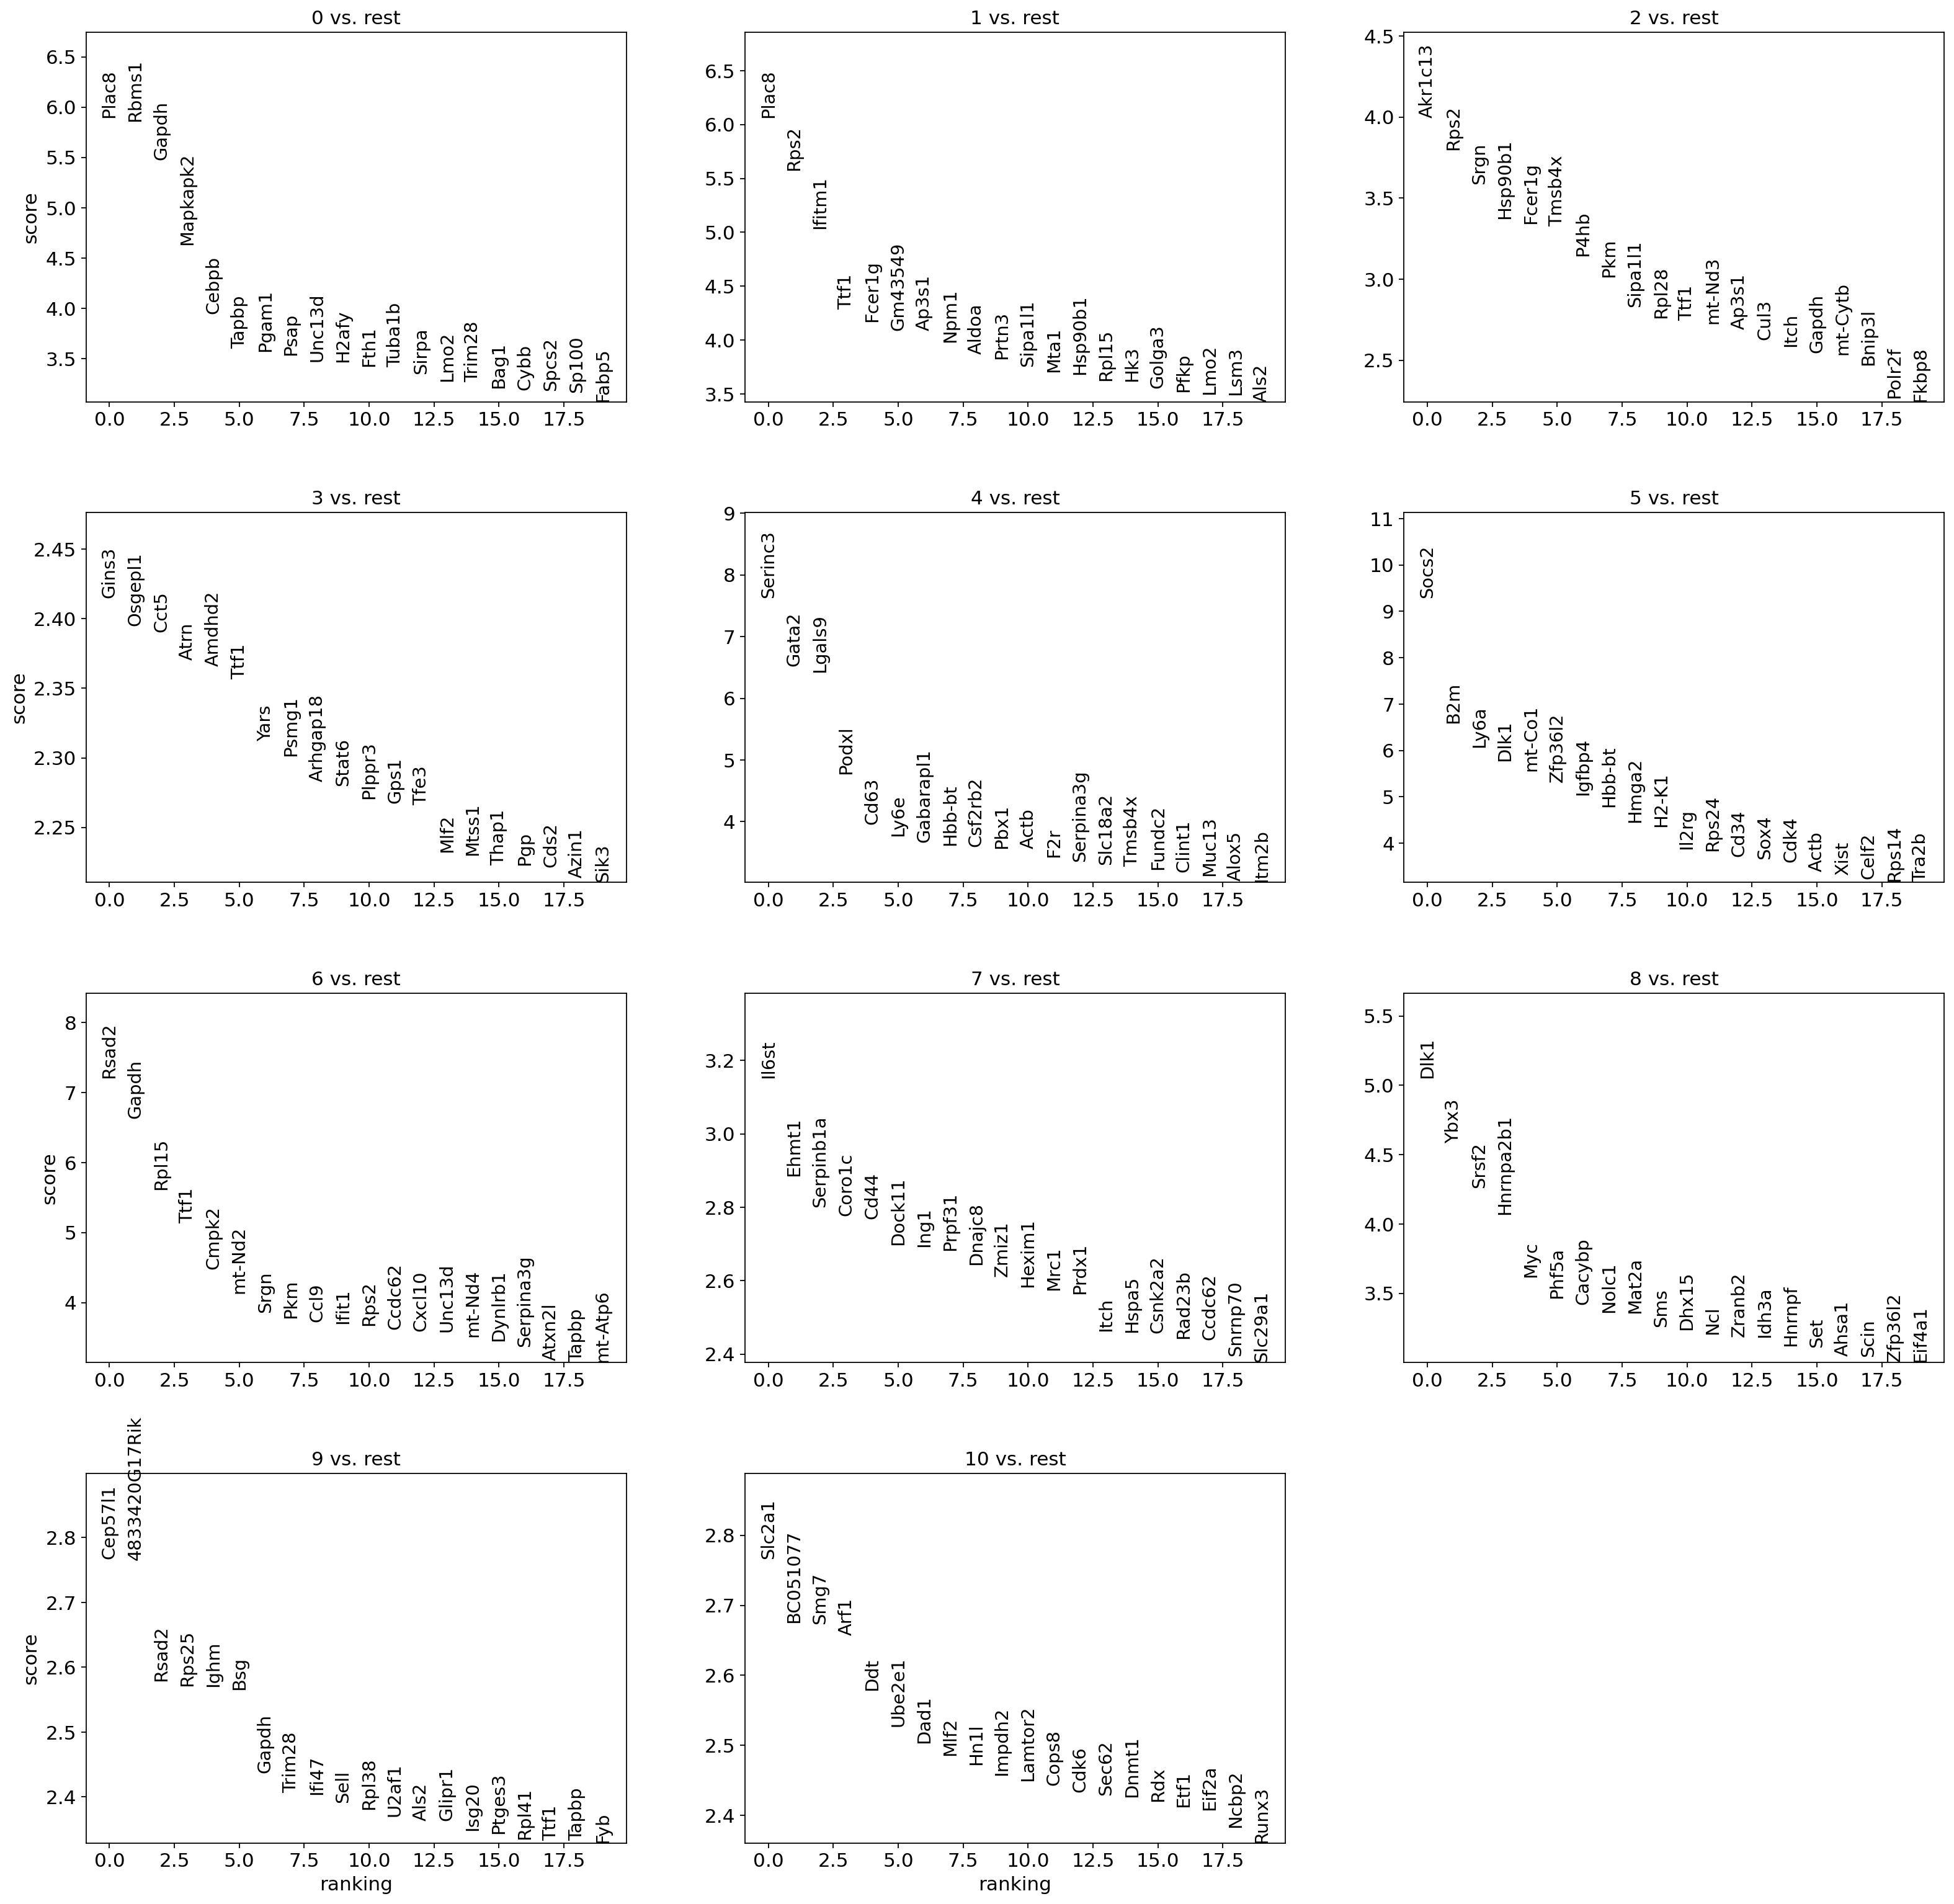

In [41]:
sc.set_figure_params(dpi_save=300, figsize=(8, 6), transparent=True)
plt.rcParams['axes.grid'] = False
sc.tl.rank_genes_groups(adata_prog1, 'meta_clones', method='wilcoxon')
sc.pl.rank_genes_groups(adata_prog1, sharey=False, ncols=3, fontsize=13)

In [43]:
df = pd.DataFrame(adata_prog1.uns['rank_genes_groups']['names'])
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10
0,Plac8,Plac8,Akr1c13,Gins3,Serinc3,Socs2,Rsad2,Il6st,Dlk1,Cep57l1,Slc2a1
1,Rbms1,Rps2,Rps2,Osgepl1,Gata2,B2m,Gapdh,Ehmt1,Ybx3,4833420G17Rik,BC051077
2,Gapdh,Ifitm1,Srgn,Cct5,Lgals9,Ly6a,Rpl15,Serpinb1a,Srsf2,Rsad2,Smg7
3,Mapkapk2,Ttf1,Hsp90b1,Atrn,Podxl,Dlk1,Ttf1,Coro1c,Hnrnpa2b1,Rps25,Arf1
4,Cebpb,Fcer1g,Fcer1g,Amdhd2,Cd63,mt-Co1,Cmpk2,Cd44,Myc,Ighm,Ddt
5,Tapbp,Gm43549,Tmsb4x,Ttf1,Ly6e,Zfp36l2,mt-Nd2,Dock11,Phf5a,Bsg,Ube2e1
6,Pgam1,Ap3s1,P4hb,Yars,Gabarapl1,Igfbp4,Srgn,Ing1,Cacybp,Gapdh,Dad1
7,Psap,Npm1,Pkm,Psmg1,Hbb-bt,Hbb-bt,Pkm,Prpf31,Nolc1,Trim28,Mlf2
8,Unc13d,Aldoa,Sipa1l1,Arhgap18,Csf2rb2,Hmga2,Ccl9,Dnajc8,Mat2a,Ifi47,Hn1l
9,H2afy,Prtn3,Rpl28,Stat6,Pbx1,H2-K1,Ifit1,Zmiz1,Sms,Sell,Impdh2


In [44]:
names = ['Hk3', 'Plac8', 'Ctsg', 'Prtn3', 'Ap3s1', 'Ttf1', 'Ifitm1']
for name in names:
    print (np.where(adata_prog1.raw.var.index == name))

(array([12259]),)
(array([18163]),)
(array([5511]),)
(array([18861]),)
(array([2717]),)
(array([23605]),)
(array([12592]),)


/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


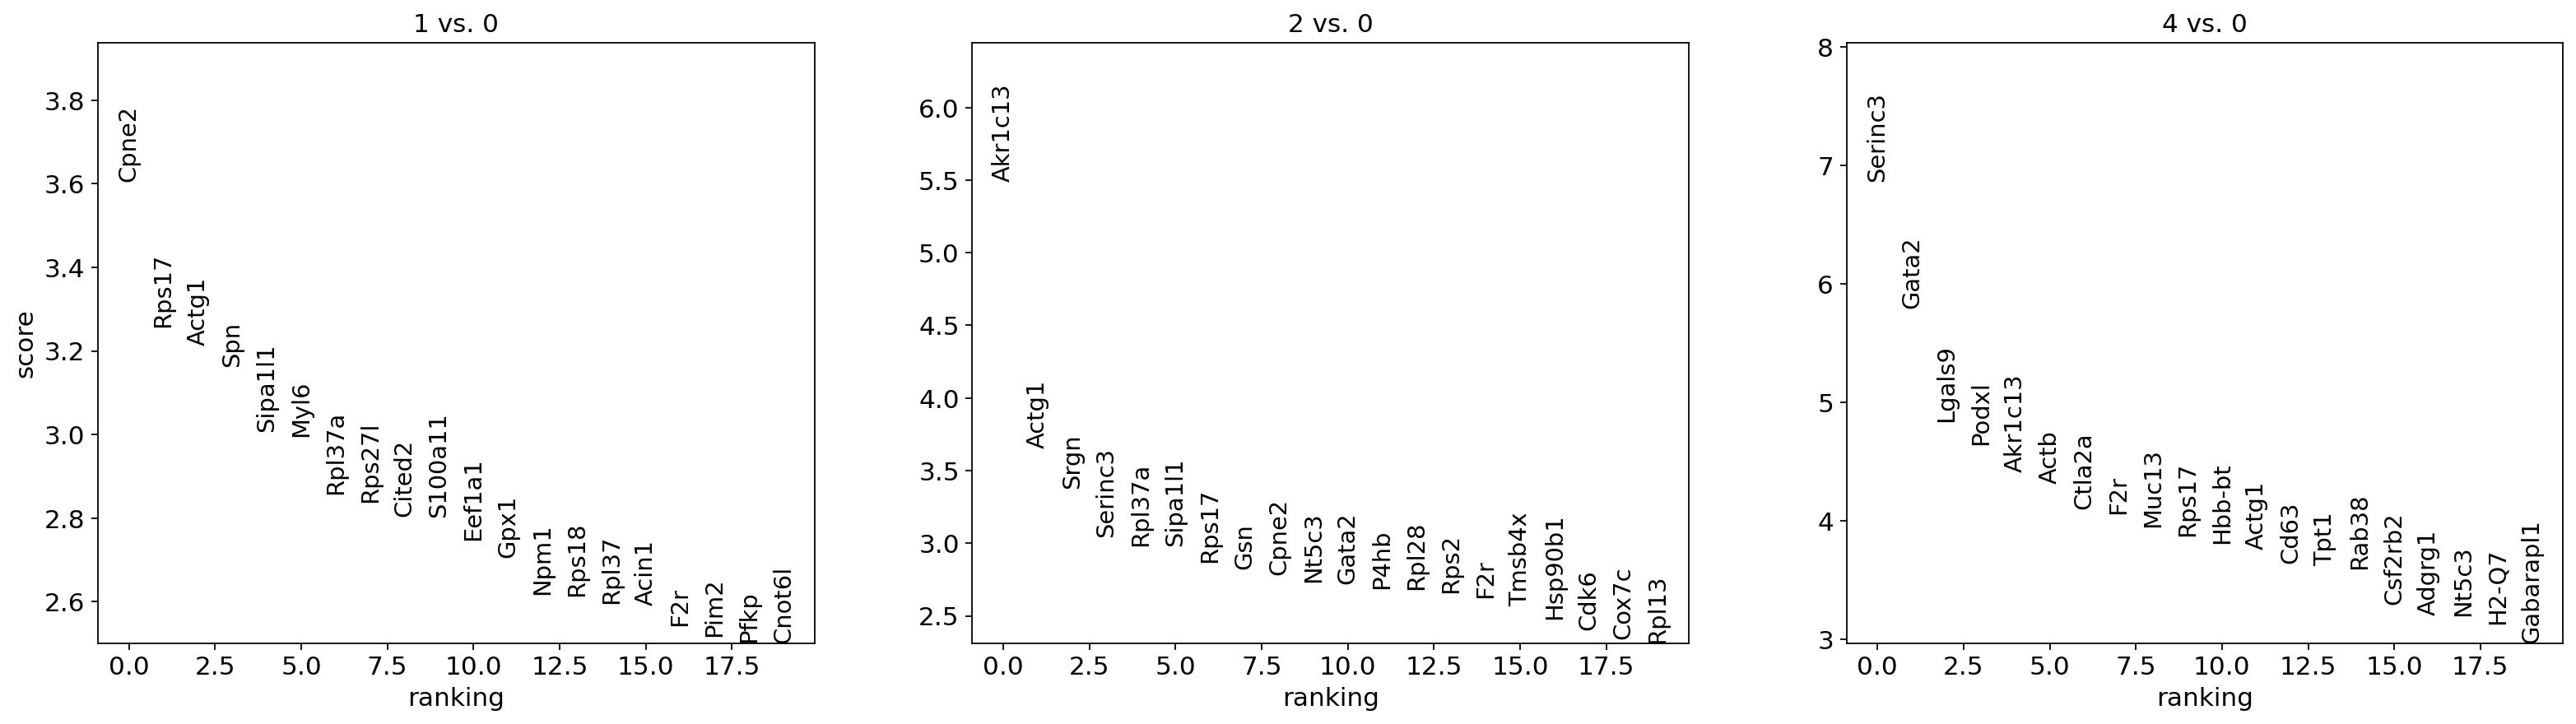

In [45]:
sc.set_figure_params(dpi_save=300, figsize=(8, 6), transparent=True)
plt.rcParams['axes.grid'] = False
sc.tl.rank_genes_groups(adata_prog1, 'meta_clones', method='wilcoxon', groups=['1', '2', '4'], reference='0')
sc.pl.rank_genes_groups(adata_prog1, sharey=False, ncols=3, fontsize=13, save='prog1_0_vs_124.svg')

In [50]:
test = adata_prog1[adata_prog1.obs['meta_clones'].values == str(1), :].copy()
refe = adata_prog1[adata_prog1.obs['meta_clones'].values == str(0), :].copy()

In [53]:
test.raw.var_names[[  685,   714,  2819,  2863,  2933,  3172,  3383,  4266,  4310,
         4313,  4761,  4899,  4960,  5467,  5596,  5908,  6568,  6873,
         7476,  7672, 10236, 11893, 12695, 12936, 13032, 13044, 13507,
        13701, 13852, 14016, 14941, 15016, 15553, 15621, 16097, 16247,
        17412, 17959, 18258, 18450, 18676, 18993, 19300, 19396, 19474,
        20091, 20270, 20645, 20975, 21065, 21082, 21115, 21450, 21900,
        22160, 22410, 22457, 22687, 22895, 24480, 24504, 24680, 24897,
        24946]]

Index(['2610037D02Rik', '2700081O15Rik', 'Arel1', 'Arhgap31', 'Arl5c',
       'Atp6ap1', 'BC035044', 'Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1',
       'Clec4a1', 'Ctc1', 'Cybb', 'Dda1', 'Eci1', 'Ephx1', 'Fcgr1', 'Fnip1',
       'Gm2694', 'Gtpbp10', 'Ighm', 'Igsf6', 'Il6st', 'Ilvbl', 'Kif15',
       'Krba1', 'Lamc1', 'Lifr', 'Mmp14', 'Mpeg1', 'Nceh1', 'Ndufaf7', 'Nudc',
       'Olfm1', 'Ostf1', 'Phf11c', 'Plin2', 'Pou2f2', 'Prkcd', 'Ptk2', 'Rasa4',
       'Rbms1', 'Rela', 'Saa3', 'Sdc4', 'Sirpa', 'Slc43a3', 'Slc9a5',
       'Slco4a1', 'Slpi', 'Spata6', 'Supv3l1', 'Tbc1d23', 'Tgfbi', 'Thoc1',
       'Tmem171', 'Tmtc4', 'Wdr81', 'Wfdc17', 'Zbed4', 'Zfp36', 'Zfp46'],
      dtype='object')

In [54]:
test.raw.var_names[[   23,  1067,  1866,  2399,  2431,  2496,  3130,  4402,  4763,
         4873,  5282,  5712,  5905,  6974,  7018,  7059,  7816, 12259,
        14448, 14535, 15328, 15548, 15624, 15652, 15731, 17712, 17715,
        17904, 18687, 19163, 19429, 19930, 20507, 20965, 22477, 22520,
        23429, 23981, 24645]]

Index(['1110001J03Rik', '4930519L02Rik', 'AI846148', 'Ak4', 'Akr1c13',
       'Alkbh5', 'Atp11b', 'Cd48', 'Chek1', 'Cited2', 'Cpne2', 'Cyth1',
       'Dcun1d5', 'Esyt1', 'Exoc1', 'F2r', 'Fut8', 'Hk3', 'Manea', 'March8',
       'Mut', 'Ncbp1', 'Ndufb2', 'Necap2', 'Nfix', 'Pcmt1', 'Pcna', 'Pfkp',
       'Prkd3', 'Rab33b', 'Rcn2', 'Rps27rt', 'Sft2d3', 'Slc39a8', 'Thy1',
       'Tiparp', 'Trmt6', 'Usp38', 'Yipf5'],
      dtype='object')

In [ ]:
# Upregulated in metaclone 1: 'Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1'
# Downregulated in metaclone 1: 'Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa'

In [ ]:
# np.where((neg_log_10 >= 2) & (lfc <=-1))
# np.where((neg_log_10 >= 2) & (lfc >=1))

In [55]:
for gene in ['Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1']:
    print(np.where(test.raw.var_names == gene))

(array([4402]),)
(array([4763]),)
(array([4873]),)
(array([17715]),)
(array([22477]),)


In [57]:
test.raw.var_names[[4402, 4763, 4873, 17715, 22477]]

Index(['Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1'], dtype='object')

In [58]:
for gene in ['Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa']:
    print(np.where(test.raw.var_names == gene))

(array([4266]),)
(array([4310]),)
(array([4313]),)
(array([4761]),)
(array([4899]),)
(array([19474]),)
(array([20645]),)


In [59]:
test.raw.var_names[[4266, 4310, 4313, 4761, 4899, 19474, 20645]]

Index(['Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa'], dtype='object')

/tmp/ipykernel_2030690/1158572910.py:6: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2030690/1158572910.py:6: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2030690/1158572910.py:7: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()


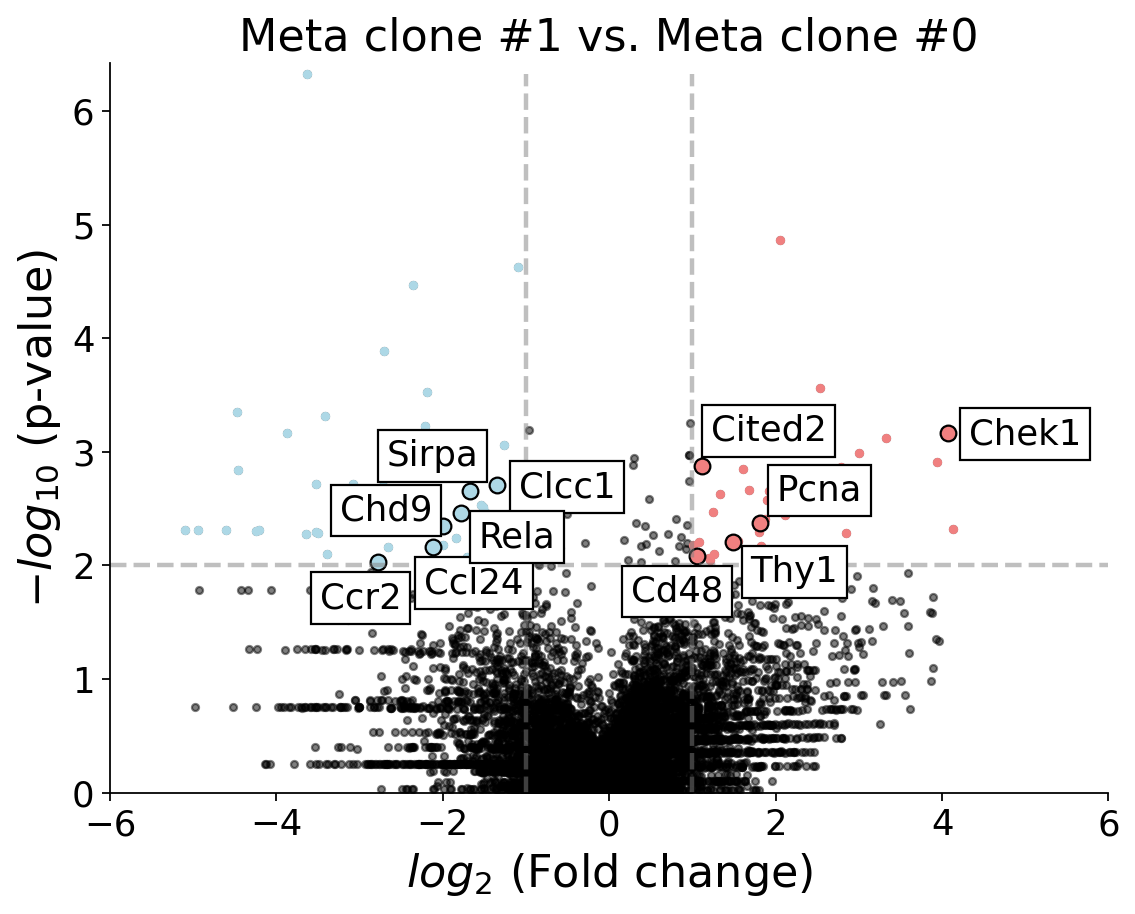

In [61]:
from scipy import stats

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.01

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.01), linestyles='dashed', xmin=-6, xmax=6, color='grey', alpha=0.5, linewidth=2)
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-6, 6])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=2)
plt.vlines(x=1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=2)
plt.scatter(lfc[np.bitwise_and(lfc > 1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 1, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -1, p_values < threshold)], color='lightblue', s=10)

index = [4402, 4763, 4873, 17715, 22477]
names = ['Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1']

for i in range(5):
    # plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] + 0.1, names[i], fontsize=16)
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightcoral',edgecolors='k', s=50)

index = [4266, 4310, 4313, 4761, 4899, 19474, 20645]
names = ['Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa']

for i in range(7):
    # plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] + 0.1, names[i], fontsize=16)
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightblue',edgecolors='k', s=50)

t = plt.text(lfc[4402] - 0.8, neg_log_10[4402] - 0.4, 'Cd48', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4763] + 0.25, neg_log_10[4763] -0.1 , 'Chek1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4873] + 0.1, neg_log_10[4873] +0.22 , 'Cited2', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[17715] +0.2, neg_log_10[17715]+0.2 , 'Pcna', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[22477] +0.21, neg_log_10[22477]-0.35 , 'Thy1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4266] - 0.1, neg_log_10[4266] - 0.4, 'Ccl24', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4313] - 0.7, neg_log_10[4313] - 0.4, 'Ccr2', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4761] - 1.24, neg_log_10[4761] + 0.05, 'Chd9', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4899] + 0.26, neg_log_10[4899] -0.11, 'Clcc1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[19474] + 0.21, neg_log_10[19474] -0.3, 'Rela', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[20645] - 1, neg_log_10[20645] +0.22, 'Sirpa', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.grid(False)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #1 vs. Meta clone #0', fontsize=20)

plt.savefig('de_mouse_prog1_0_vs_1.svg', dpi=300, bbox_inches='tight', transparent=True)

In [62]:
lfc[index[1]]# this gene has infinite lfc

-inf

### Panel D

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWa

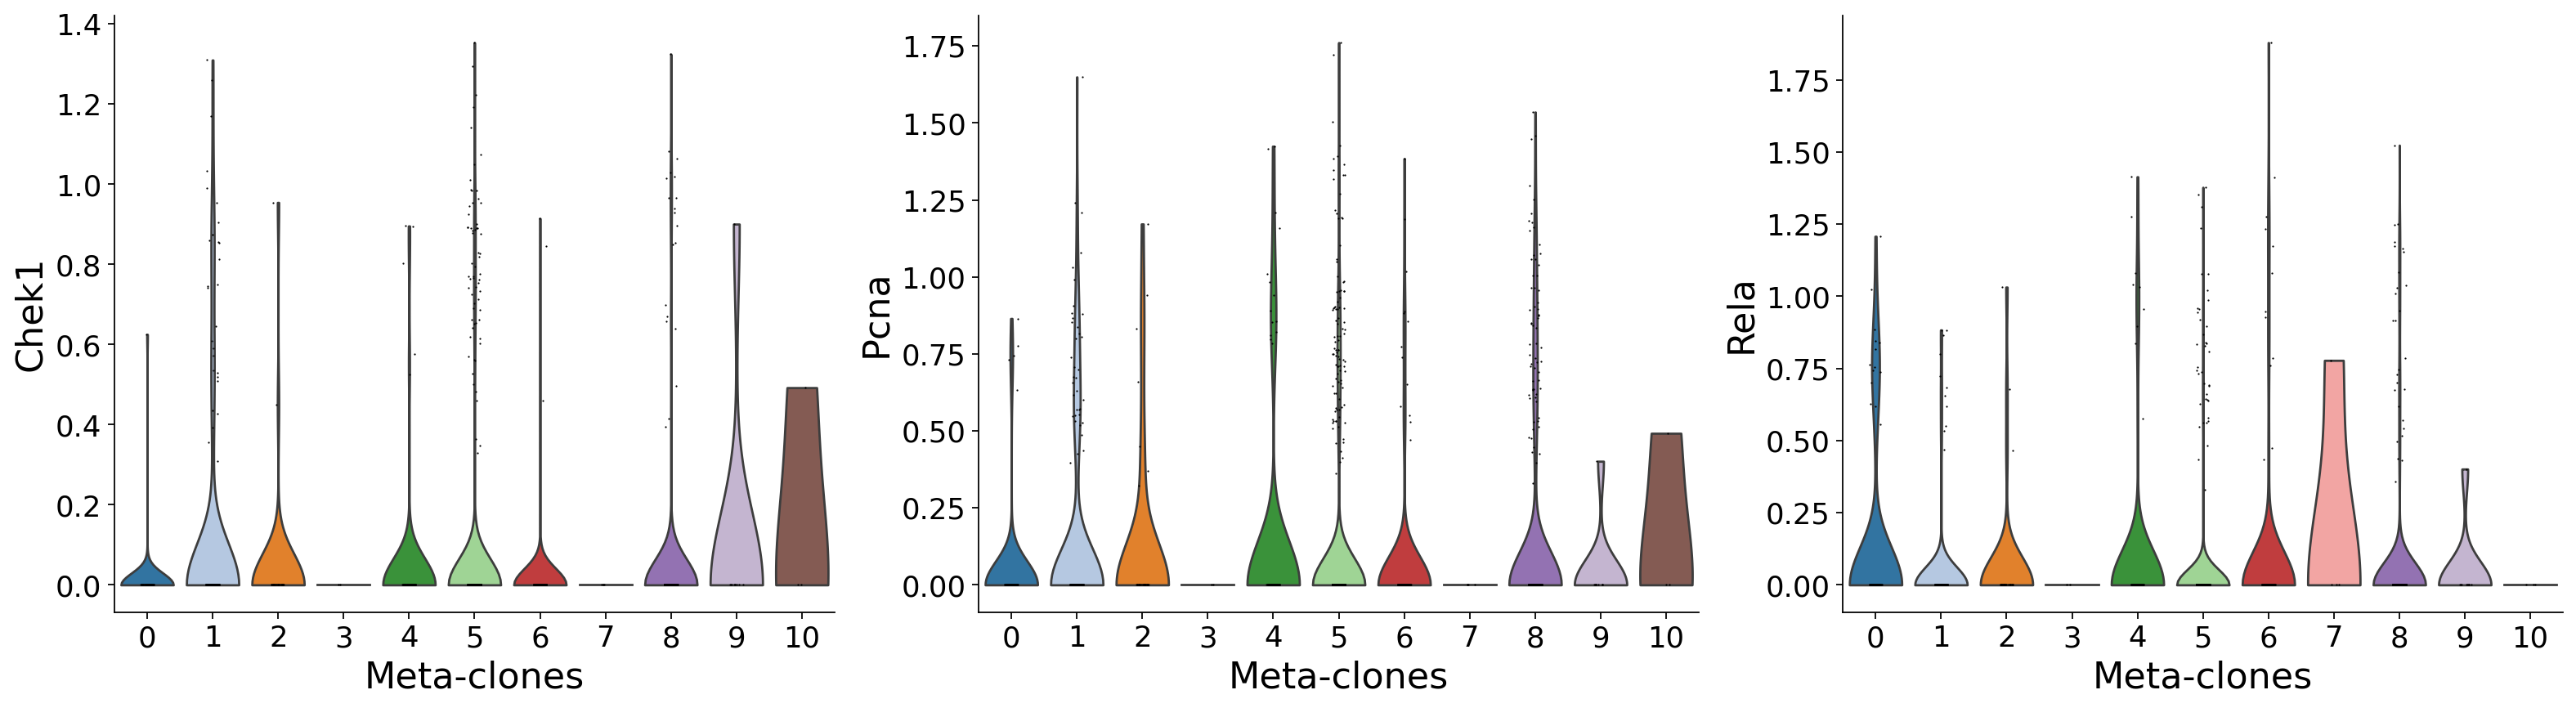

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
sc.set_figure_params(dpi_save=300, figsize=(8, 6))
names = ['Chek1',  'Pcna', 'Rela']

for idx, gene in enumerate(names):
    sc.pl.violin(adata_prog1, gene, groupby='meta_clones', ax=axes[idx], show=False, palette='tab20')
    axes[idx].set_xlabel('Meta-clones')
    axes[idx].yaxis.grid(False)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    axes[idx].set_xlabel('Meta-clones', fontsize=20)  # Adjust fontsize as needed
    axes[idx].set_ylabel(gene, fontsize=20)  # You can set y-label if needed
    
    # Set tick parameters for x and y axes
    axes[idx].tick_params(axis='x', labelsize=16)  # Adjust x-tick font size
    axes[idx].tick_params(axis='y', labelsize=16)  

plt.savefig('gene_mouse_prog1_0_vs_1.svg', bbox_inches='tight', transparent=True, dpi=300)

### Panel Prog_1 Unused

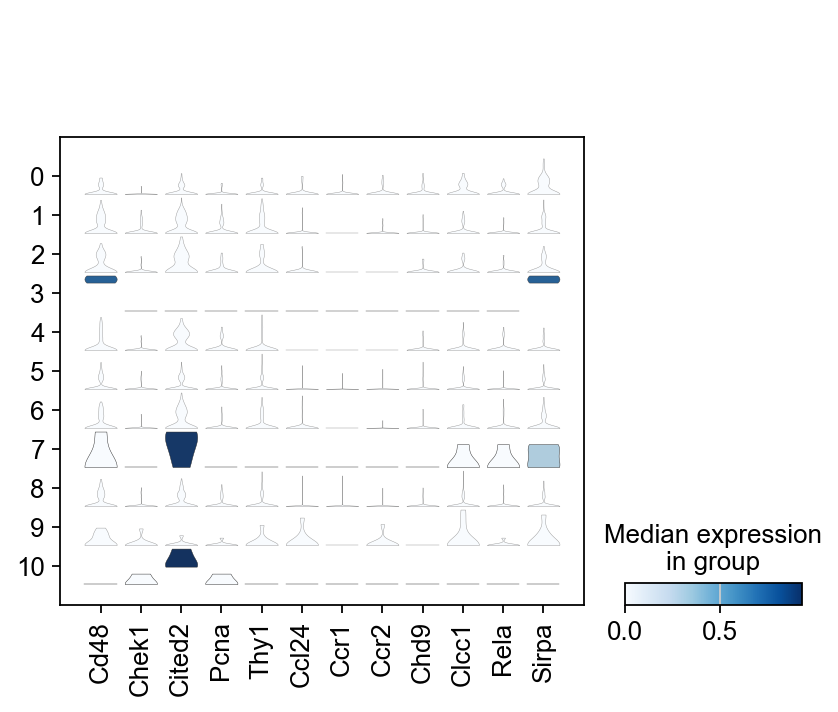

<Figure size 1280x480 with 0 Axes>

In [ ]:
sc.set_figure_params(dpi_save=300, figsize=(16, 6), transparent=True)
sc.pl.stacked_violin(adata_hsc, 
    ['Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1','Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa'], 
    groupby='Meta clones')

plt.savefig('data_figures/stack_plot_mouse_hsc.svg', bbox_inches='tight', transparent=True, dpi=300)

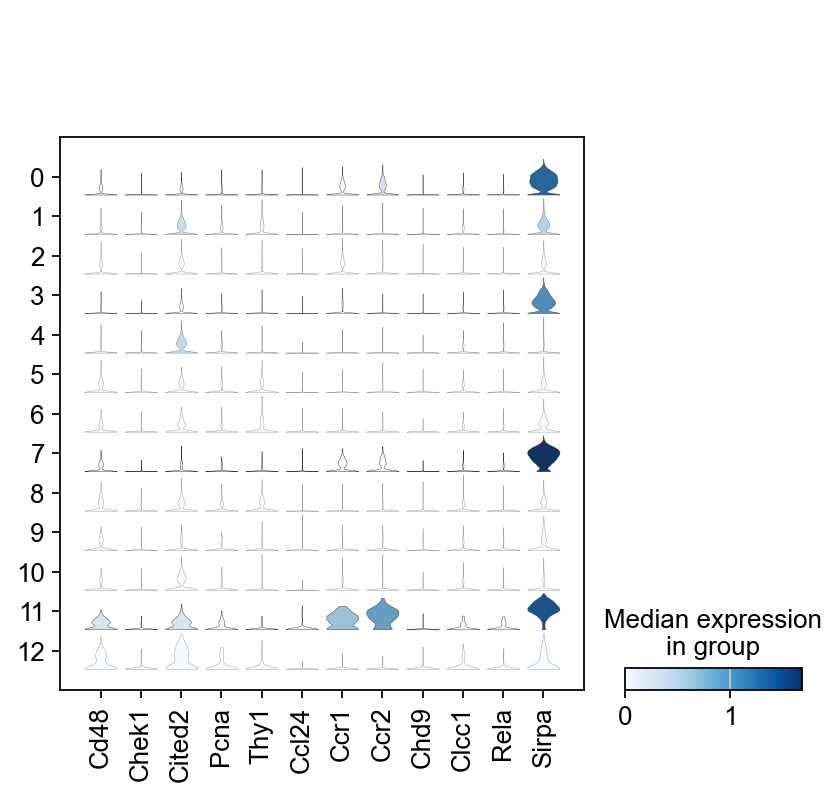

<Figure size 1280x480 with 0 Axes>

In [ ]:
sc.set_figure_params(dpi_save=300, figsize=(16, 6), transparent=True)
sc.pl.stacked_violin(adata, 
    ['Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1','Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa'], 
    groupby='Meta clones')
plt.savefig('data_figures/stack_plot_mouse_all.svg', bbox_inches='tight', transparent=True, dpi=300)

### Panel E

In [66]:
adata_prog2.shape

(5759, 4995)

In [69]:
for i in range(13):
    print (f'Meta-Clone {i}:', np.sum(adata_prog2.obs['meta_clones'].values == str(i)))

Meta-Clone 0: 835
Meta-Clone 1: 1143
Meta-Clone 2: 237
Meta-Clone 3: 290
Meta-Clone 4: 117
Meta-Clone 5: 798
Meta-Clone 6: 403
Meta-Clone 7: 145
Meta-Clone 8: 1694
Meta-Clone 9: 23
Meta-Clone 10: 5
Meta-Clone 11: 0
Meta-Clone 12: 69


In [ ]:
del adata_prog2.uns['log1p']

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


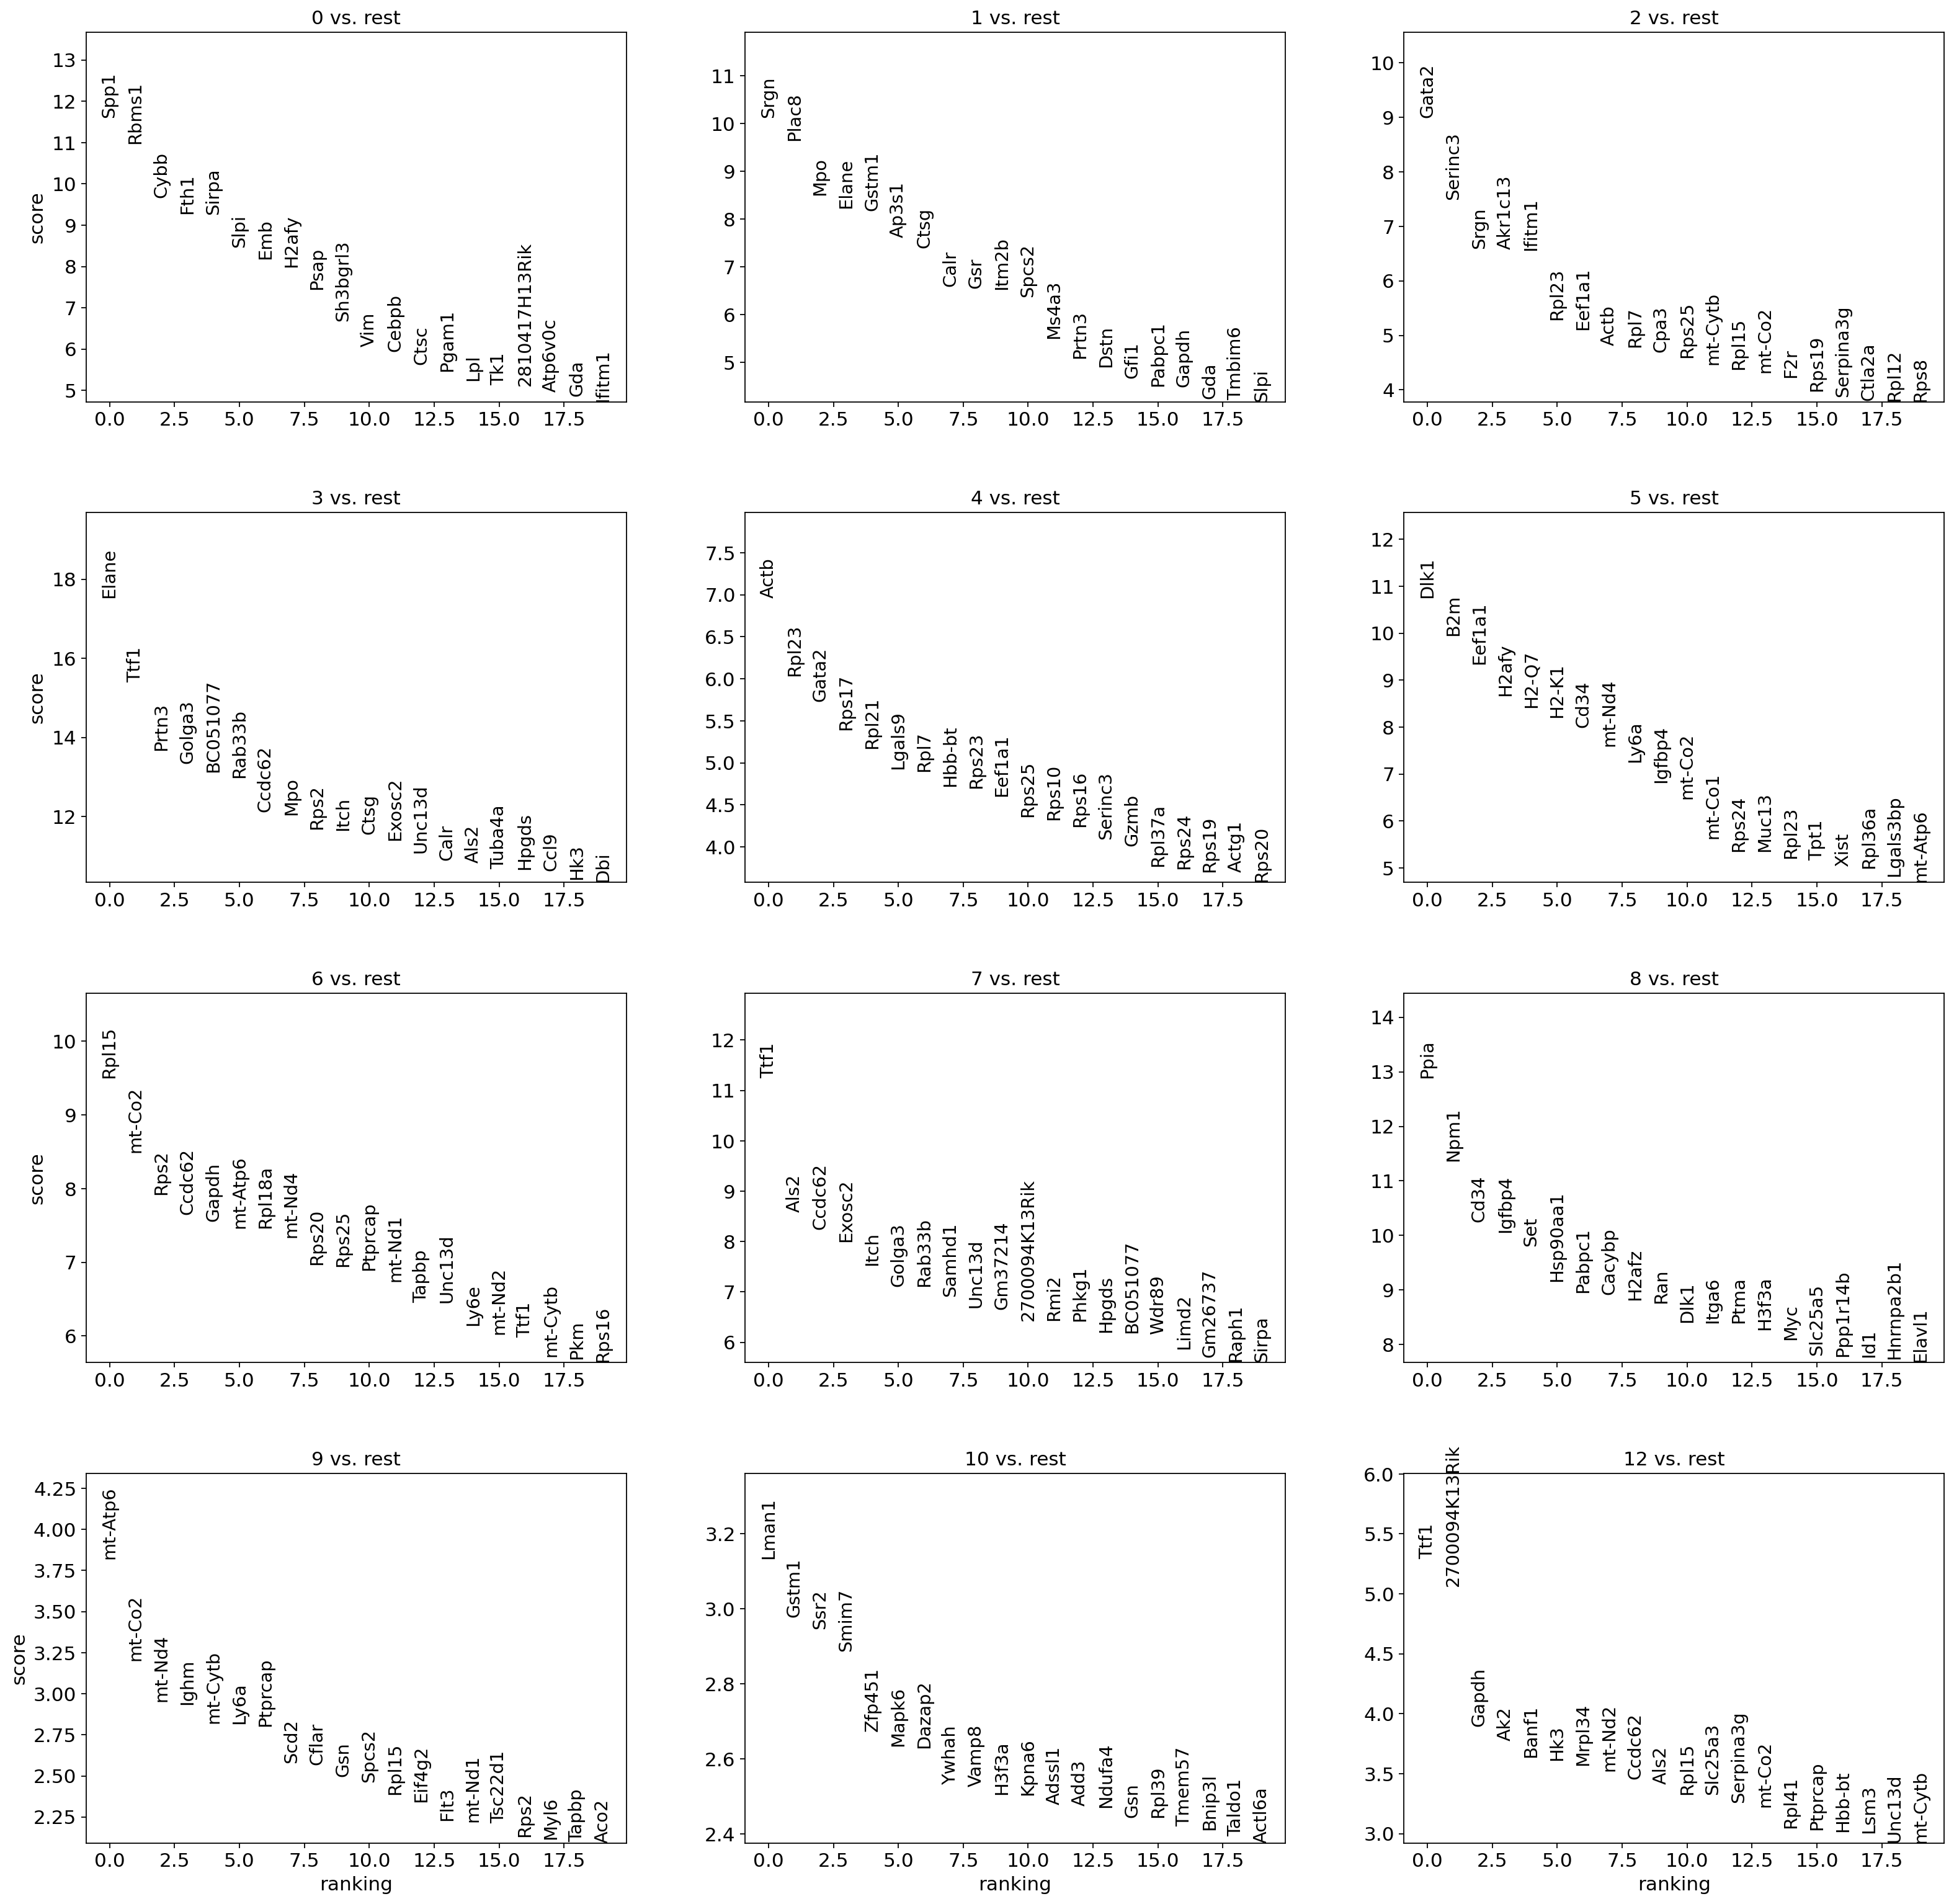

In [76]:
# sc.set_figure_params(dpi_save=300, figsize=(8, 6), transparent=True)
plt.rcParams['axes.grid'] = False
sc.tl.rank_genes_groups(adata_prog2, 'meta_clones', method='wilcoxon')
sc.pl.rank_genes_groups(adata_prog2, sharey=False, ncols=3, fontsize=13)

In [78]:
df = pd.DataFrame(adata_prog2.uns['rank_genes_groups']['names'])
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,12
0,Spp1,Srgn,Gata2,Elane,Actb,Dlk1,Rpl15,Ttf1,Ppia,mt-Atp6,Lman1,Ttf1
1,Rbms1,Plac8,Serinc3,Ttf1,Rpl23,B2m,mt-Co2,Als2,Npm1,mt-Co2,Gstm1,2700094K13Rik
2,Cybb,Mpo,Srgn,Prtn3,Gata2,Eef1a1,Rps2,Ccdc62,Cd34,mt-Nd4,Ssr2,Gapdh
3,Fth1,Elane,Akr1c13,Golga3,Rps17,H2afy,Ccdc62,Exosc2,Igfbp4,Ighm,Smim7,Ak2
4,Sirpa,Gstm1,Ifitm1,BC051077,Rpl21,H2-Q7,Gapdh,Itch,Set,mt-Cytb,Zfp451,Banf1
5,Slpi,Ap3s1,Rpl23,Rab33b,Lgals9,H2-K1,mt-Atp6,Golga3,Hsp90aa1,Ly6a,Mapk6,Hk3
6,Emb,Ctsg,Eef1a1,Ccdc62,Rpl7,Cd34,Rpl18a,Rab33b,Pabpc1,Ptprcap,Dazap2,Mrpl34
7,H2afy,Calr,Actb,Mpo,Hbb-bt,mt-Nd4,mt-Nd4,Samhd1,Cacybp,Scd2,Ywhah,mt-Nd2
8,Psap,Gsr,Rpl7,Rps2,Rps23,Ly6a,Rps20,Unc13d,H2afz,Cflar,Vamp8,Ccdc62
9,Sh3bgrl3,Itm2b,Cpa3,Itch,Eef1a1,Igfbp4,Rps25,Gm37214,Ran,Gsn,H3f3a,Als2


/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old be

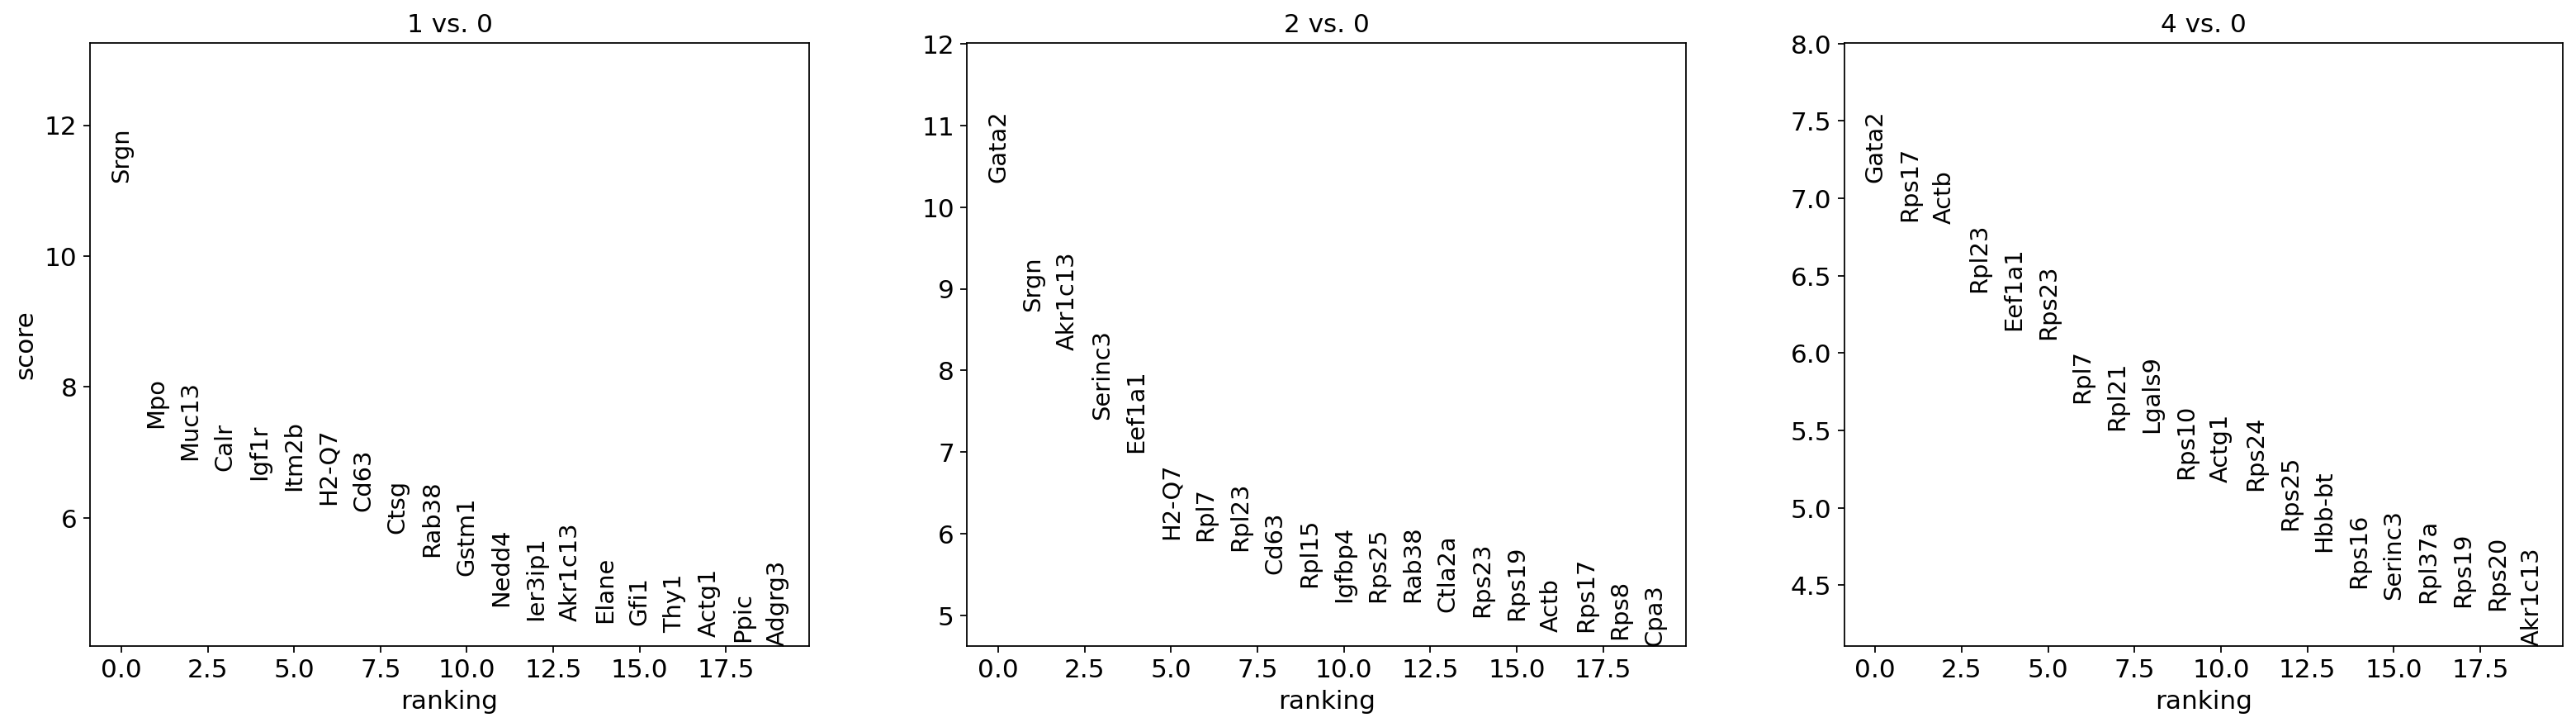

In [79]:
# sc.set_figure_params(dpi_save=300, figsize=(8, 6), transparent=True)
plt.rcParams['axes.grid'] = False
sc.tl.rank_genes_groups(adata_prog2, 'meta_clones', method='wilcoxon', groups=['1', '2', '4'], reference='0')
sc.pl.rank_genes_groups(adata_prog2, sharey=False, ncols=3, fontsize=13, save='rank_genes_prog2.svg')

In [82]:
test = adata_prog2[adata_prog2.obs['meta_clones'].values == str(1), :].copy()
refe = adata_prog2[adata_prog2.obs['meta_clones'].values == str(0), :].copy()

In [83]:
test.raw.X.todense().shape

(1143, 25289)

In [84]:
refe.raw.X.todense().shape

(835, 25289)

In [ ]:
test.raw.var_names[[  685,   714,  2819,  2863,  2933,  3172,  3383,  4266,  4310,
         4313,  4761,  4899,  4960,  5467,  5596,  5908,  6568,  6873,
         7476,  7672, 10236, 11893, 12695, 12936, 13032, 13044, 13507,
        13701, 13852, 14016, 14941, 15016, 15553, 15621, 16097, 16247,
        17412, 17959, 18258, 18450, 18676, 18993, 19300, 19396, 19474,
        20091, 20270, 20645, 20975, 21065, 21082, 21115, 21450, 21900,
        22160, 22410, 22457, 22687, 22895, 24480, 24504, 24680, 24897,
        24946]]

Index(['2610037D02Rik', '2700081O15Rik', 'Arel1', 'Arhgap31', 'Arl5c',
       'Atp6ap1', 'BC035044', 'Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1',
       'Clec4a1', 'Ctc1', 'Cybb', 'Dda1', 'Eci1', 'Ephx1', 'Fcgr1', 'Fnip1',
       'Gm2694', 'Gtpbp10', 'Ighm', 'Igsf6', 'Il6st', 'Ilvbl', 'Kif15',
       'Krba1', 'Lamc1', 'Lifr', 'Mmp14', 'Mpeg1', 'Nceh1', 'Ndufaf7', 'Nudc',
       'Olfm1', 'Ostf1', 'Phf11c', 'Plin2', 'Pou2f2', 'Prkcd', 'Ptk2', 'Rasa4',
       'Rbms1', 'Rela', 'Saa3', 'Sdc4', 'Sirpa', 'Slc43a3', 'Slc9a5',
       'Slco4a1', 'Slpi', 'Spata6', 'Supv3l1', 'Tbc1d23', 'Tgfbi', 'Thoc1',
       'Tmem171', 'Tmtc4', 'Wdr81', 'Wfdc17', 'Zbed4', 'Zfp36', 'Zfp46'],
      dtype='object')

In [ ]:
test.raw.var_names[[   23,  1067,  1866,  2399,  2431,  2496,  3130,  4402,  4763,
         4873,  5282,  5712,  5905,  6974,  7018,  7059,  7816, 12259,
        14448, 14535, 15328, 15548, 15624, 15652, 15731, 17712, 17715,
        17904, 18687, 19163, 19429, 19930, 20507, 20965, 22477, 22520,
        23429, 23981, 24645]]

Index(['1110001J03Rik', '4930519L02Rik', 'AI846148', 'Ak4', 'Akr1c13',
       'Alkbh5', 'Atp11b', 'Cd48', 'Chek1', 'Cited2', 'Cpne2', 'Cyth1',
       'Dcun1d5', 'Esyt1', 'Exoc1', 'F2r', 'Fut8', 'Hk3', 'Manea', 'March8',
       'Mut', 'Ncbp1', 'Ndufb2', 'Necap2', 'Nfix', 'Pcmt1', 'Pcna', 'Pfkp',
       'Prkd3', 'Rab33b', 'Rcn2', 'Rps27rt', 'Sft2d3', 'Slc39a8', 'Thy1',
       'Tiparp', 'Trmt6', 'Usp38', 'Yipf5'],
      dtype='object')

In [ ]:
# Upregulated in metaclone 1: 'Cd48', 'Chek1', 'Cited2', 'Pcna', 'Thy1'
# Downregulated in metaclone 1: 'Ccl24', 'Ccr1', 'Ccr2', 'Chd9', 'Clcc1', 'Rela', 'Sirpa'

In [ ]:
# np.where((neg_log_10 >= 2) & (lfc <=-1))
# np.where((neg_log_10 >= 2) & (lfc >=1))

In [85]:
for gene in ['Alox5', 'Cd200r1', 'Cebpe', 'Gfi1', 'S1pr4']:
    print(np.where(test.raw.var_names == gene))

(array([2507]),)
(array([4351]),)
(array([4585]),)
(array([8053]),)
(array([20087]),)


In [86]:
for gene in ['Ccr1', 'Ccr2', 'Cd33', 'Cd52', 'Csf1r', 'Irf8', 'Spp1']:
    print(np.where( test.raw.var_names == gene))

(array([4310]),)
(array([4313]),)
(array([4387]),)
(array([4404]),)
(array([5405]),)
(array([13168]),)
(array([21536]),)


/tmp/ipykernel_2030690/4255029433.py:6: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2030690/4255029433.py:6: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2030690/4255029433.py:7: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()


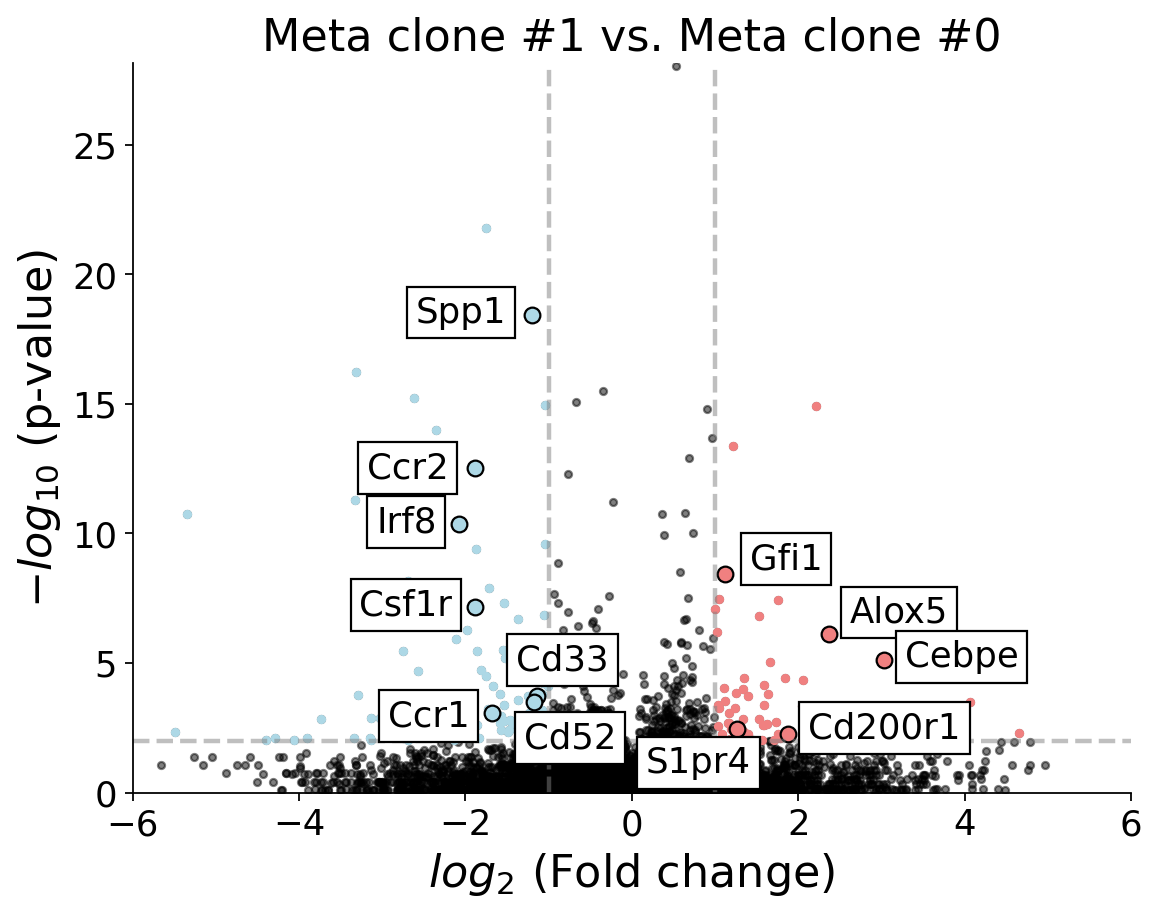

In [88]:
from scipy import stats

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.01

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.01), linestyles='dashed', xmin=-6, xmax=6, color='grey', alpha=0.5, linewidth=2)
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-6, 6])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=2)
plt.vlines(x=1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=2)
plt.scatter(lfc[np.bitwise_and(lfc > 1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 1, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -1, p_values < threshold)], color='lightblue', s=10)

index = [2507, 4351, 4585, 8053, 20087]
names = ['Alox5', 'Cd200r1', 'Cebpe', 'Gfi1', 'S1pr4']

for i in range(5):
    # plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] + 0.1, names[i], fontsize=16)
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightcoral',edgecolors='k', s=50)

index = [4310, 4313, 4387, 4404, 5405, 13168, 21536]
names = ['Ccr1', 'Ccr2', 'Cd33', 'Cd52', 'Csf1r', 'Irf8', 'Spp1']

for i in range(7):
    # plt.text(lfc[index[i]] + 0.1, neg_log_10[index[i]] + 0.1, names[i], fontsize=16)
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightblue',edgecolors='k', s=50)

t = plt.text(lfc[2507] + 0.25, neg_log_10[2507] + 0.45, 'Alox5', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4351] + 0.25, neg_log_10[4351] -0.15 , 'Cd200r1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4585] + 0.25, neg_log_10[4585] -0.25 , 'Cebpe', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[8053] +0.3, neg_log_10[8053]+0.2 , 'Gfi1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[20087] -1.1, neg_log_10[20087]-1.7 , 'S1pr4', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4310] - 1.25, neg_log_10[4310] - 0.5, 'Ccr1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4313] - 1.3, neg_log_10[4313] - .4, 'Ccr2', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4387] - .25, neg_log_10[4387] + 1, 'Cd33', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[4404] - 0.12, neg_log_10[4404] -1.8, 'Cd52', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[5405] - 1.39, neg_log_10[5405] -0.3, 'Csf1r', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[13168] - 1, neg_log_10[13168] -0.3, 'Irf8', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[21536] - 1.4, neg_log_10[21536] -0.3, 'Spp1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.grid(False)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #1 vs. Meta clone #0', fontsize=20)

plt.savefig('./de_mouse_prog2_0_vs_1.svg', bbox_inches='tight', transparent=True, dpi=300)

### Panel F

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWa

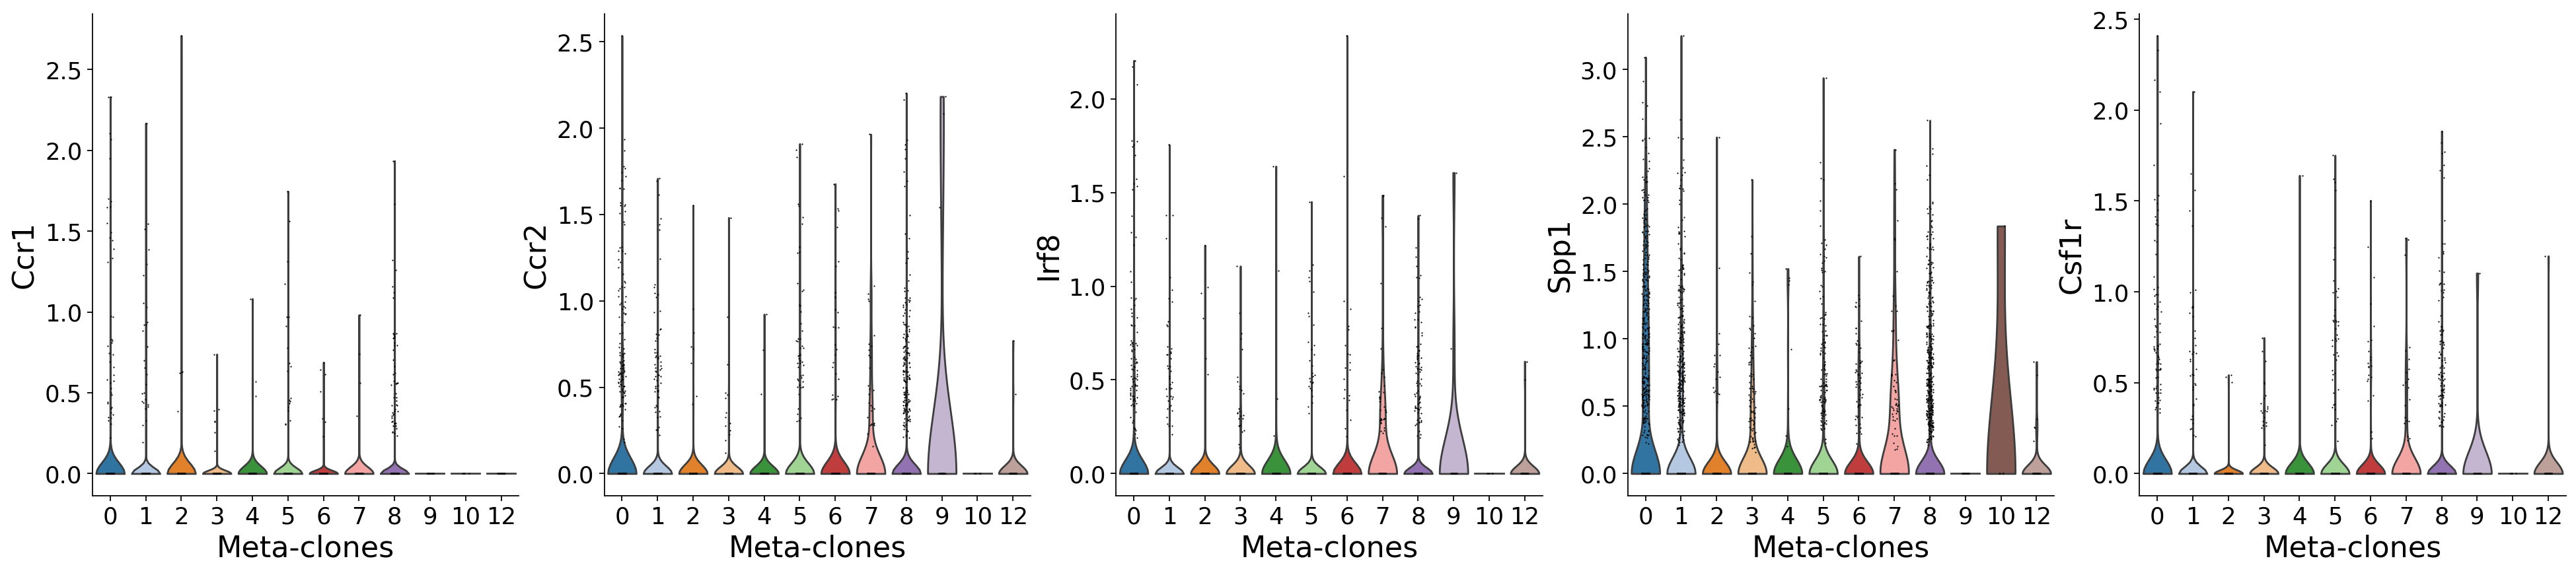

In [91]:
fig, axes = plt.subplots(1, 5, figsize=(30, 6))
names = ['Ccr1', 'Ccr2', 'Irf8', 'Spp1', 'Csf1r']#'Alox5','Cd200r1','Cebpe','Gfi1','S1pr4','Ccr1','Ccr2','Cd33','Cd52','Csf1r','Irf8','Spp1'

for idx, gene in enumerate(names):
    sc.pl.violin(adata_prog2, gene, groupby='meta_clones', ax=axes[idx], show=False, palette='tab20')
    axes[idx].set_xlabel('Meta-clones')
    axes[idx].yaxis.grid(False)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    axes[idx].set_xlabel('Meta-clones', fontsize=20)  # Adjust fontsize as needed
    axes[idx].set_ylabel(gene, fontsize=20)  # You can set y-label if needed
    
    # Set tick parameters for x and y axes
    axes[idx].tick_params(axis='x', labelsize=16)  # Adjust x-tick font size
    axes[idx].tick_params(axis='y', labelsize=16)  

plt.savefig('./gene_mouse_prog2_0_vs_1.svg', bbox_inches='tight', transparent=True, dpi=300)

### Panel Prog_2 Unused

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:406: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(_matrix.stack(dropna=False))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

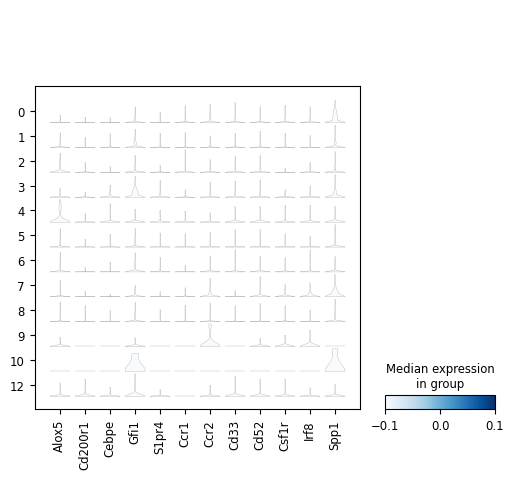

<Figure size 640x480 with 0 Axes>

In [ ]:
# sc.set_figure_params(dpi_save=300, figsize=(16, 6), transparent=True)
sc.pl.stacked_violin(adata_hsc, 
    ['Alox5','Cd200r1','Cebpe','Gfi1','S1pr4','Ccr1','Ccr2','Cd33','Cd52','Csf1r','Irf8','Spp1'], 
    groupby='Meta clones')

plt.savefig('./stack_plot_mouse_prog2.svg', bbox_inches='tight', transparent=True, dpi=300)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:406: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(_matrix.stack(dropna=False))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_stacked_violin.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

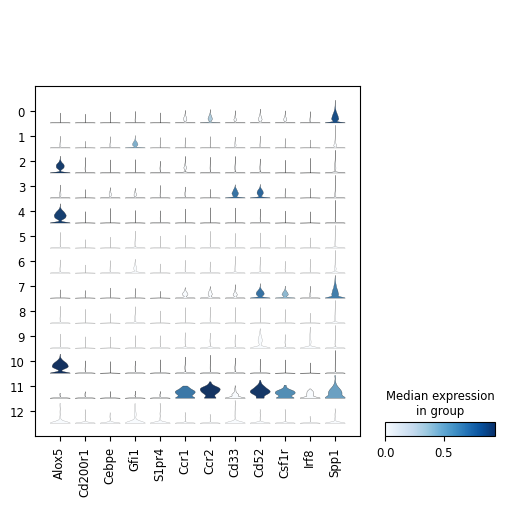

<Figure size 640x480 with 0 Axes>

In [ ]:
# sc.set_figure_params(dpi_save=300, figsize=(16, 6), transparent=True)
sc.pl.stacked_violin(adata, 
    ['Alox5','Cd200r1','Cebpe','Gfi1','S1pr4','Ccr1','Ccr2','Cd33','Cd52','Csf1r','Irf8','Spp1'], 
    groupby='Meta clones')
plt.savefig('./stack_plot_mouse_all.svg', bbox_inches='tight', transparent=True, dpi=300)

### Panel G

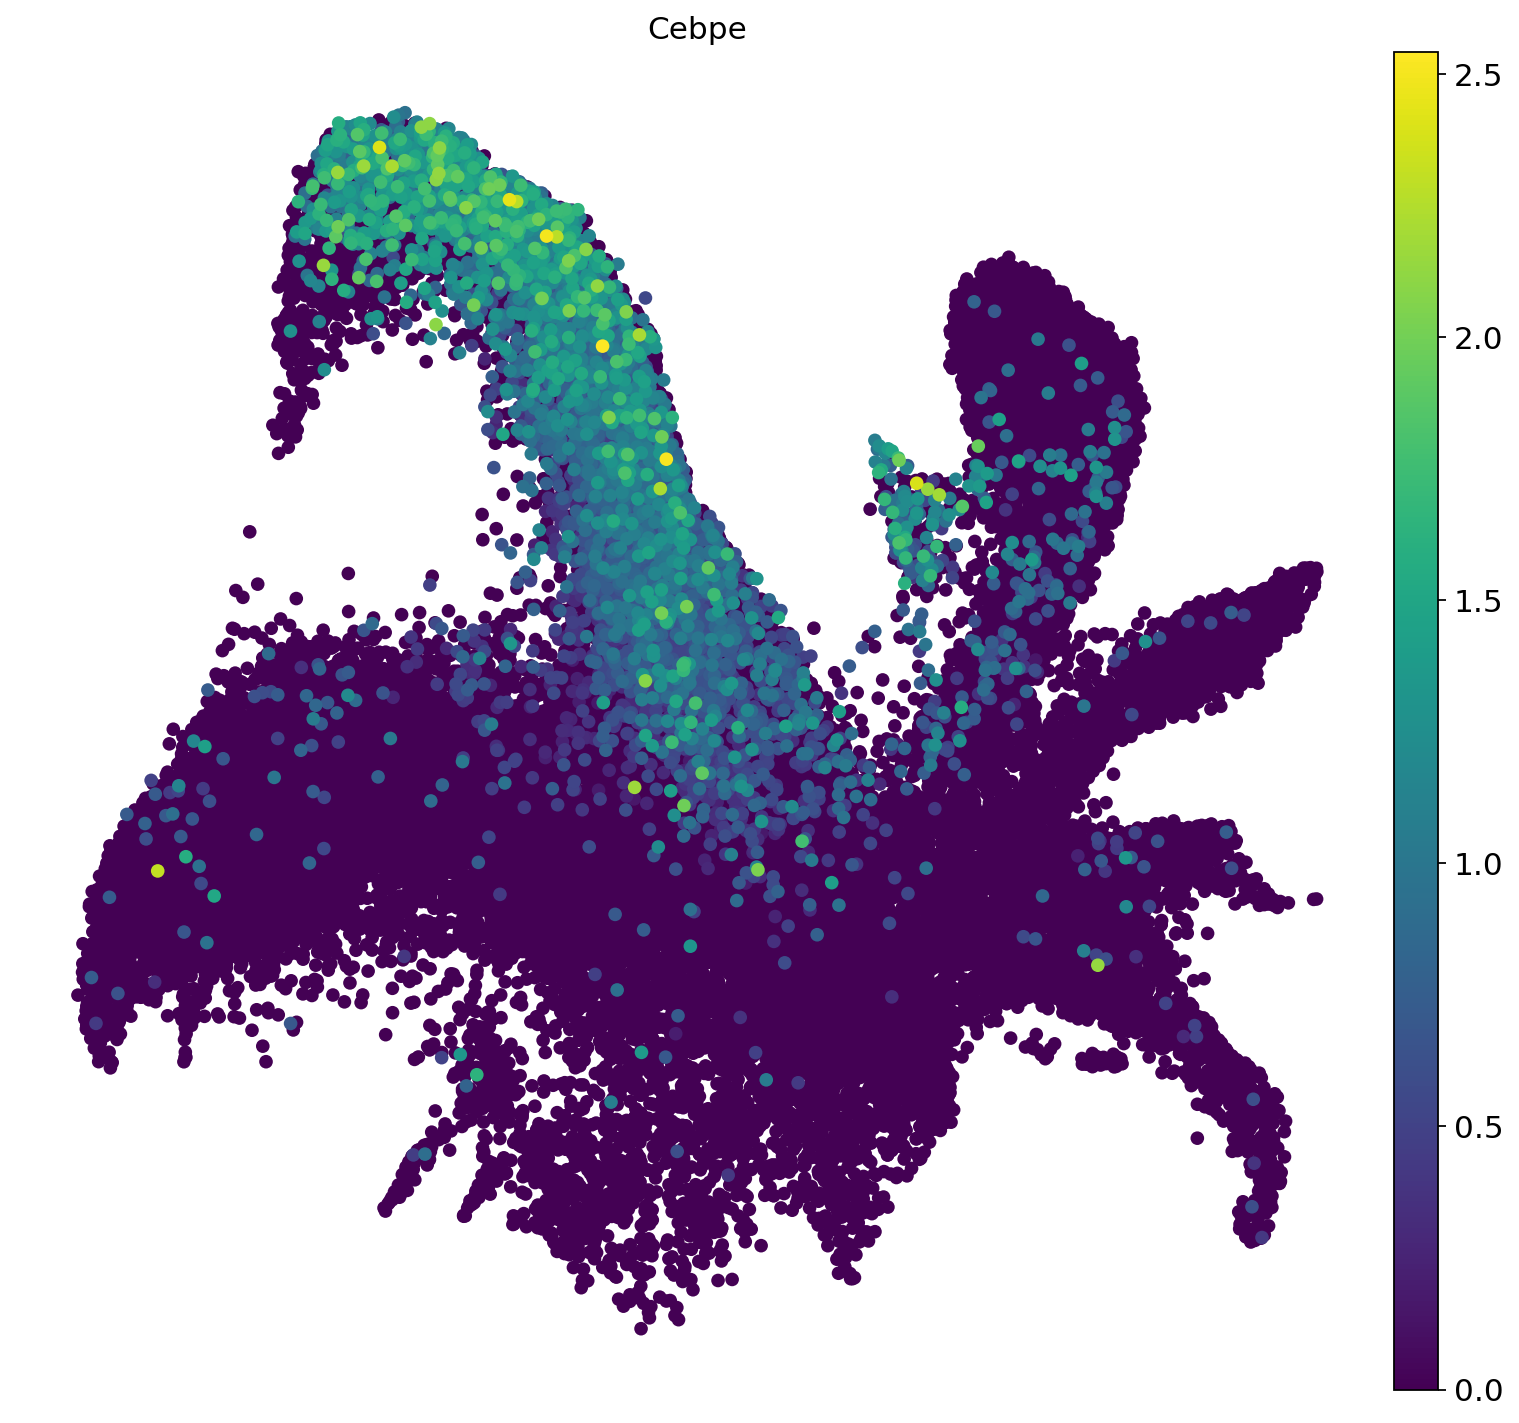

In [106]:
sc.set_figure_params(dpi_save=300, figsize=(12, 11), transparent=True)
# sc.pl.umap(adata, color=['Alox5', 'Cd200r1', 'Cebpe', 'Gfi1', 'S1pr4', 'Ccr1', 'Ccr2', 'Cd33', 'Cd52', 'Csf1r', 'Irf8', 'Spp1'], ncols=3, frameon=False, save='umap_genes.svg')
sc.pl.umap(adata, color=['Cebpe'], frameon=False, save='umap_genes.svg', size=150)

### Panel H

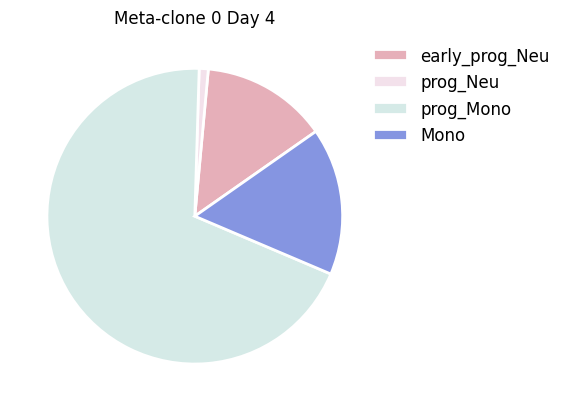

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([6,0.43,30.0,7.0],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=35,counterclock=True);
plt.title('Meta-clone 0 Day 4')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)


plt.savefig("pie_chart_mc0_day4_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

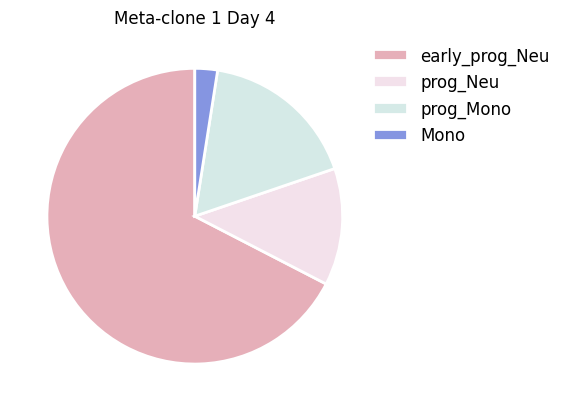

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([3,0.57,0.77,0.11],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=90,counterclock=True);
plt.title('Meta-clone 1 Day 4')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.savefig("pie_chart_mc1_day4_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

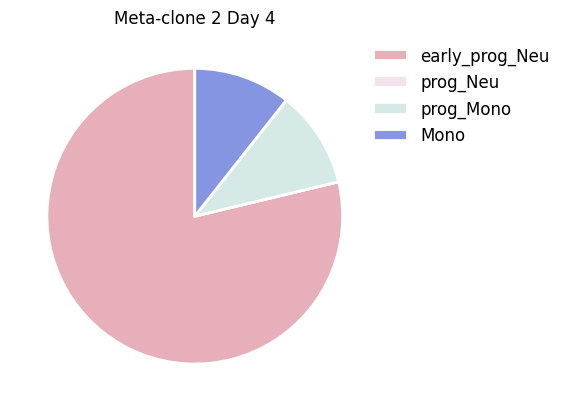

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([4,0,0.54,0.54],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=90,counterclock=True);
plt.title('Meta-clone 2 Day 4')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.savefig("pie_chart_mc2_day4_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

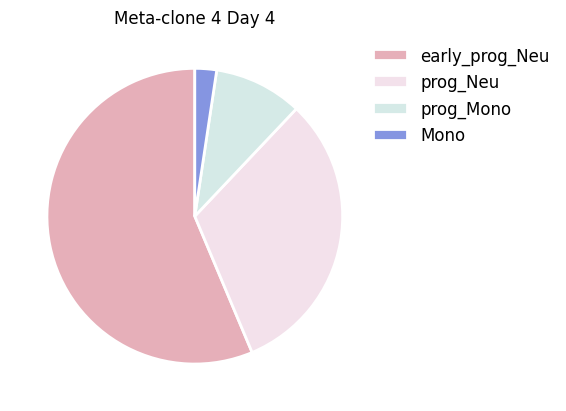

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([1804,1012,310,76],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=90,counterclock=True);
plt.title('Meta-clone 4 Day 4')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.savefig("pie_chart_mc4_day4_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

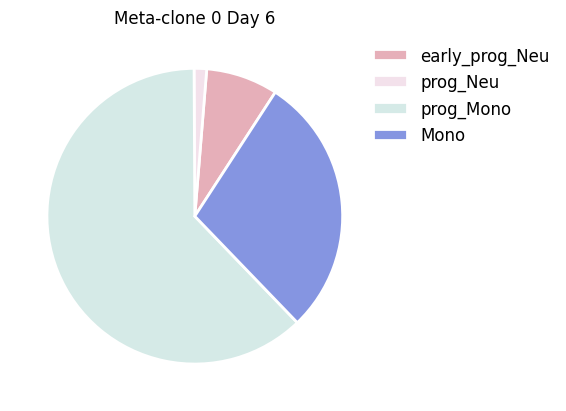

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([115,20,907,418],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=57,counterclock=True);
plt.title('Meta-clone 0 Day 6')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)


plt.savefig("pie_chart_mc0_day6_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

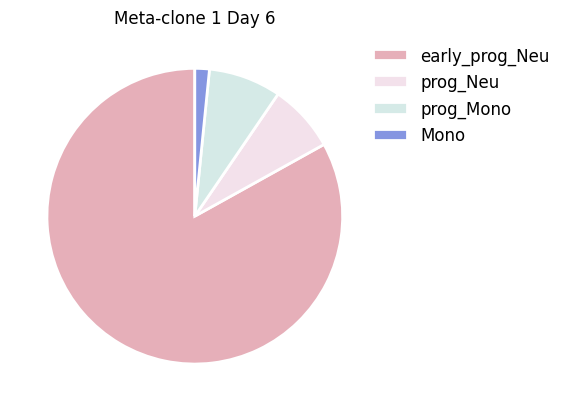

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([157,14,15,3],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=90,counterclock=True);
plt.title('Meta-clone 1 Day 6')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.savefig("pie_chart_mc1_day6_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

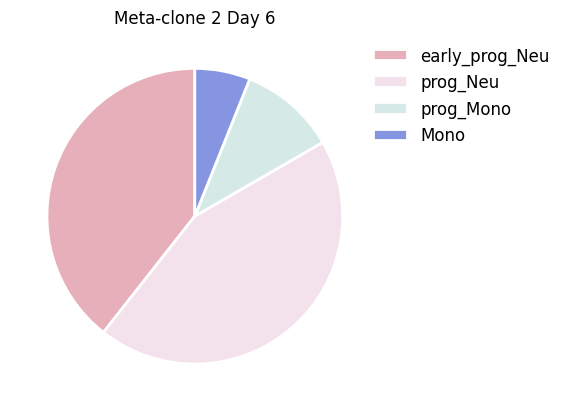

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([26,29,7,4],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=90,counterclock=True);
plt.title('Meta-clone 2 Day 6')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.savefig("pie_chart_mc2_day6_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)

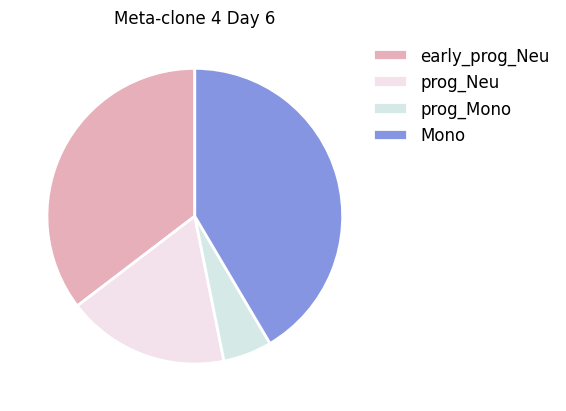

In [ ]:
labels = ['early_prog_Neu','prog_Neu','prog_Mono','Mono']

patches, texts = plt.pie([1.79,0.9,0.27,2.1],colors=['#e6afb9', '#f3e1eb', '#d5eae7','#8595e1'], wedgeprops = {"edgecolor" : "white", 
                      'linewidth': 2, 
                      'antialiased': True},startangle=90,counterclock=True);
plt.title('Meta-clone 4 Day 6')
plt.legend(patches, labels, loc="best", fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)

plt.savefig("pie_chart_mc4_day6_mouse.svg", bbox_inches='tight', transparent=True, dpi=300)